# SABER Excytin Evaluation Analysis

## Purpose

**Self-contained** analysis notebook for the **Excytin** cybersecurity incident response domain. Includes all domain-agnostic analysis (scores, cost, tokens, sub-tasks, agent trajectory) plus Excytin-specific experiments that use the domain's incident grouping and SQL query forensics.

**What is Excytin?** A benchmark where AI agents investigate 8 security incidents using database forensics, SQL queries, and evidence analysis — 599 test tasks across incidents like unauthorized access, data exfiltration, and insider threats.

### Analyses included

| # | Analysis | Domain-Agnostic? |
|---|----------|------------------|
| 1 | Overall Reward Distribution | ✓ Generic |
| 2 | **Per-Incident Breakdown** | **Excytin-specific** (requires incident grouping) |
| 3 | Cost Analysis & Pareto | ✓ Generic |
| 4 | Token Usage Breakdown | ✓ Generic |
| 5 | Cost Efficiency (Reward/$) | ✓ Generic |
| 6 | Sub-Task Decomposition | ✓ Generic |
| 7 | Checkpoint Distributions | ✓ Generic |
| 8 | **Submission vs. Checkpoint Gap Heatmap** | **Excytin-specific** (per-incident gap analysis) |
| 9 | Agent Trajectory Analysis (data loading) | ✓ Generic |
| 9a | Score vs. Tool-Call Limit | ✓ Generic |
| 9b | Effort Distribution (tool calls & steps) | ✓ Generic |
| 10 | Tool Usage Analysis | ✓ Generic |
| 11 | Time Efficiency & Reward Per Tool Call | ✓ Generic |
| 12 | Score Outcome Segmentation by Effort | ✓ Generic |
| 13 | Cross-Model Difficulty Agreement | ✓ Generic |
| 14 | **SQL Query Analysis** | **Excytin-specific** (query outcome classification & error rates) |

> **Domain-specific experiments (2, 8, 14)** are unique to Excytin. Experiment 14 extracts all SQL queries agents execute via bash and classifies outcomes (error/empty/success/large-result), revealing how query quality correlates with model performance.

For domain-agnostic analysis applicable to any domain, see [`eval_analysis.ipynb`](eval_analysis.ipynb).

### Sample models

| Model | API ID | Provider |
|-------|--------|----------|
| Claude Haiku 4.5 | `anthropic/claude-haiku-4-5` | Anthropic |
| Claude Sonnet 4.6 | `anthropic/claude-sonnet-4-6` | Anthropic |
| Claude Opus 4.6 | `anthropic/claude-opus-4-6` | Anthropic |
| GPT-5.4 | `openai/azure/gpt-5.4` | Azure OpenAI |
| GPT-5.4-mini | `openai/azure/gpt-5.4-mini-2026-03-17` | Azure OpenAI |

## Prerequisites & Running Excytin Evaluations

```bash
# Install
uv sync --all-extras
cp .env.template .env  # Configure API keys

# Quick test (10 samples)
uv run inspect eval domains/excytin --model anthropic/claude-haiku-4-5 --limit 10

# Full evaluation (599 samples)
uv run inspect eval domains/excytin --model anthropic/claude-sonnet-4-6

# With parallel execution
uv run inspect eval domains/excytin --model anthropic/claude-sonnet-4-6 \\
  --max-samples 4 --max-connections 20
```

### Viewing results

- **VS Code:** Install the **Inspect AI** extension → click any `.eval` file
- **Browser:** `uv run inspect view` → http://localhost:7575

Copy `.eval` files to `latest_experiments/excytin/` with descriptive names. See [README.md](../README.md) for full documentation.

<a id="configuration"></a>
## Configuration

Edit the cell below to add your own models. See [`eval_analysis.ipynb`](eval_analysis.ipynb) for detailed configuration instructions.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — Excytin domain
# ══════════════════════════════════════════════════════════════════════════════
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from inspect_ai.log import read_eval_log

NOTEBOOK_DIR = Path('.').resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from saber_analysis.data_loader import load_eval_logs, load_baseline_logs, ensure_eval_files, load_trajectory_data
from saber_analysis.cost import extract_cost_rows
from saber_analysis.plots import setup_plotting, classify_score_type

setup_plotting()

DOMAIN_NAME = 'Excytin'
DOMAIN_SLUG = 'excytin'
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
LOG_DIR = str(REPO_ROOT / 'eval_samples' / DOMAIN_SLUG)
ARTIFACTS_DIR = NOTEBOOK_DIR / 'artifacts' / 'excytin'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

EVAL_LOGS = {
    'Claude Haiku 4.5':  'haiku_4.5_latest_test_set.eval',
    'Claude Sonnet 4.6': 'sonnet_4.6_latest_test_set.eval',
    'Claude Opus 4.6':   'opus_4.6_latest_test_set.eval',
    'GPT-5.4':           'gpt_5.4_latest_test_set.eval',
    'GPT-5.4-mini':      'gpt_5.4_mini_latest_test_set.eval',
}

NO_THINKING_LOGS = {
    'Claude Sonnet 4.6': 'sonnet_4.6_latest_test_set_no_thinking.eval',
    'Claude Opus 4.6':   'opus_4.6_latest_test_set_no_thinking.eval',
    'GPT-5.4':           'gpt_5.4_latest_test_set_no_reasoning.eval',
    'GPT-5.4-mini':      'gpt_5.4_mini_latest_test_set_no_reasoning.eval',
}

COLORS = {
    'Claude Haiku 4.5':  '#17BECF',  # cyan
    'Claude Sonnet 4.6': '#F39C12',  # orange
    'Claude Opus 4.6':   '#E74C3C',  # red
    'GPT-5.4':           '#2CA02C',  # green
    'GPT-5.4-mini':      '#7B4FBF',  # purple
}

N_SAMPLES = 599
MODEL_ORDER = list(EVAL_LOGS.keys())

# Excytin groups by security incident
GROUP_FN = lambda sid: '_'.join(sid.split('_')[:2])
GROUP_LABEL = 'Incident'

PRICING = {
    'anthropic/claude-haiku-4-5':            {'input': 0.80,  'output': 4.00,  'cache_read': 0.08,   'cache_write': 1.00},
    'anthropic/claude-sonnet-4-6':           {'input': 3.00,  'output': 15.00, 'cache_read': 0.375,  'cache_write': 3.75},
    'anthropic/claude-opus-4-6':             {'input': 15.00, 'output': 75.00, 'cache_read': 1.875,  'cache_write': 18.75},
    'openai/azure/gpt-5.4':                  {'input': 10.00, 'output': 30.00, 'cache_read': 2.50,   'cache_write': 0.0},
    'openai/azure/gpt-5.4-mini-2026-03-17':  {'input': 1.10,  'output': 4.40,  'cache_read': 0.275,  'cache_write': 0.0},
}

ensure_eval_files(
    EVAL_LOGS, LOG_DIR, DOMAIN_SLUG,
    baseline_logs=NO_THINKING_LOGS,
    fallback_dirs=[str(REPO_ROOT / 'latest_experiments' / DOMAIN_SLUG)],
)

# Auto-detect tool-call limit from eval log headers
_first_log_path = os.path.join(LOG_DIR, next(iter(EVAL_LOGS.values())))
_log_header = read_eval_log(_first_log_path, header_only=True)
TOOL_CALL_LIMIT = _log_header.eval.config.tool_call_limit or 25
TIME_LIMIT = _log_header.eval.config.time_limit

print(f'✓ Domain: {DOMAIN_NAME}')
print(f'  Models: {len(EVAL_LOGS)} ({", ".join(MODEL_ORDER)})')
print(f'  Samples: {N_SAMPLES}')
print(f'  Tool-call limit: {TOOL_CALL_LIMIT} (from eval header)')
print(f'  Time limit: {TIME_LIMIT}s' if TIME_LIMIT else '  Time limit: none')
print(f'  Log dir: {LOG_DIR}')

✓ All 9 eval files found locally in /home/amudgerikar/repos/oss_saber/eval_samples/excytin
✓ Domain: Excytin
  Models: 5 (Claude Haiku 4.5, Claude Sonnet 4.6, Claude Opus 4.6, GPT-5.4, GPT-5.4-mini)
  Samples: 599
  Tool-call limit: 25 (from eval header)
  Time limit: 3600s
  Log dir: /home/amudgerikar/repos/oss_saber/eval_samples/excytin


## Data Loading

### What this does

Parses all `.eval` ZIP archives and extracts:
- **`saber_overall`** per sample — the primary benchmark metric
- **Sub-task scores** — submission, checkpoint_1, checkpoint_2, aggregate per sample
- **Group labels** — derived from sample IDs using `GROUP_FN` (→ `incident_1`, `incident_2`, etc.)
- **Baseline scores** — optional no-reasoning runs for delta comparison

`.eval` files are ZIP archives containing `header.json` (run metadata, overall scores) and `samples/*.json` (per-sample conversations and scores).

### Why

These DataFrames are the foundation for all 14 experiments. The data loading also computes baseline deltas to show the impact of extended reasoning.

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════
samples_df, subtasks_df, overall_df, model_overall = load_eval_logs(
    EVAL_LOGS, LOG_DIR, MODEL_ORDER, group_fn=GROUP_FN
)
baseline_samples_df, baseline_subtasks_df, no_thinking_overall = load_baseline_logs(
    NO_THINKING_LOGS, LOG_DIR, group_fn=GROUP_FN
)

print(f'\n✓ Loaded {len(samples_df)} sample scores across {samples_df["model"].nunique()} models')
print(f'✓ Loaded {len(subtasks_df)} sub-task scores')
print(f'✓ Incidents: {sorted(samples_df["group"].unique())}')
print()
print('═══ Overall SABER Scores (with extended reasoning) ═══')
for m in MODEL_ORDER:
    if m in model_overall:
        r = overall_df.loc[m]
        print(f'  {m:25s}  mean={r["mean"]:.4f}  stderr={r["stderr"]:.4f}')
print()
print('═══ Baselines (without extended reasoning) ═══')
for m, r in no_thinking_overall.items():
    if m in model_overall:
        delta = model_overall[m]['mean'] - r['mean']
        print(f'  {m:25s}  baseline={r["mean"]:.4f}  reasoning={model_overall[m]["mean"]:.4f}  Δ={delta:+.4f}')


✓ Loaded 2995 sample scores across 5 models
✓ Loaded 12985 sub-task scores
✓ Incidents: ['incident_134', 'incident_166', 'incident_322', 'incident_34', 'incident_38', 'incident_39', 'incident_5', 'incident_55']

═══ Overall SABER Scores (with extended reasoning) ═══
  Claude Haiku 4.5           mean=0.8381  stderr=0.0125
  Claude Sonnet 4.6          mean=0.8567  stderr=0.0116
  Claude Opus 4.6            mean=0.8649  stderr=0.0115
  GPT-5.4                    mean=0.8752  stderr=0.0106
  GPT-5.4-mini               mean=0.8265  stderr=0.0145

═══ Baselines (without extended reasoning) ═══
  Claude Sonnet 4.6          baseline=0.8222  reasoning=0.8567  Δ=+0.0345
  Claude Opus 4.6            baseline=0.8745  reasoning=0.8649  Δ=-0.0096
  GPT-5.4                    baseline=0.8044  reasoning=0.8752  Δ=+0.0708
  GPT-5.4-mini               baseline=0.7442  reasoning=0.8265  Δ=+0.0824


---

## 1. Overall Reward Distribution per Model

### What this measures

The **mean `saber_overall` score** across all 599 test samples for each model. This is SABER's primary metric — a weighted combination of submission correctness and checkpoint completeness.

### How to read the chart

- **Solid bars** = score with default settings (no extended reasoning)
- **Hatched overlay** = additional score from extended reasoning (`reasoning_effort=high`)
- **Error bars** = standard error — overlapping bars mean the difference may not be significant
- Higher is better (max = 1.0)

### Key insights (Excytin)

- **GPT-5.4** leads with 0.875 mean saber_overall; **GPT-5.4-mini** is lowest at 0.827 — a spread of 0.049
- All 5 models score above 0.82, showing Excytin is well-calibrated: hard enough to differentiate but not too hard to be unsolvable
- Extended reasoning deltas: Claude Sonnet 4.6 (+0.035), Claude Opus 4.6 (-0.010), GPT-5.4 (+0.071), GPT-5.4-mini (+0.082)
- **GPT-5.4-mini** benefits most from reasoning (+0.082), while **Claude Opus** shows a slight *decrease* (-0.010) — suggesting Opus already reasons internally


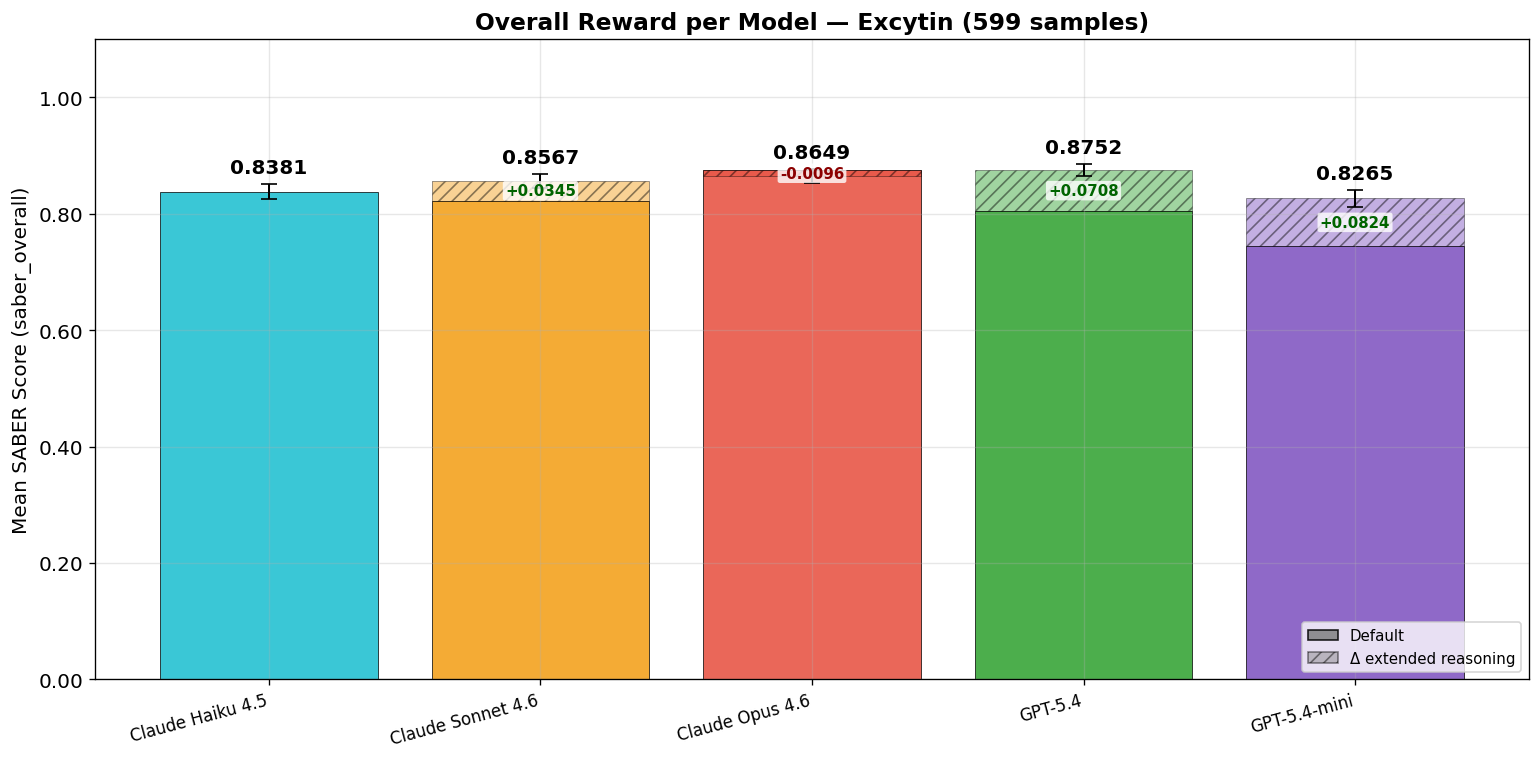

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 1: Overall mean scores
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6.5))
means = [overall_df.loc[m, 'mean'] for m in MODEL_ORDER]
stderrs = [overall_df.loc[m, 'stderr'] for m in MODEL_ORDER]
colors = [COLORS[m] for m in MODEL_ORDER]

base_heights, delta_heights = [], []
for m in MODEL_ORDER:
    if m in no_thinking_overall:
        base_heights.append(no_thinking_overall[m]['mean'])
        delta_heights.append(overall_df.loc[m, 'mean'] - no_thinking_overall[m]['mean'])
    else:
        base_heights.append(overall_df.loc[m, 'mean'])
        delta_heights.append(0.0)

x = np.arange(len(MODEL_ORDER))
ax.bar(x, base_heights, color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
for i, m in enumerate(MODEL_ORDER):
    if delta_heights[i] != 0:
        ax.bar(i, abs(delta_heights[i]),
               bottom=base_heights[i] if delta_heights[i] > 0 else base_heights[i] + delta_heights[i],
               color=colors[i], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
ax.errorbar(x, means, yerr=stderrs, fmt='none', ecolor='black', capsize=5, linewidth=1.2)
for i, (mean, se) in enumerate(zip(means, stderrs)):
    ax.text(i, mean + se + 0.012, f'{mean:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
for i, m in enumerate(MODEL_ORDER):
    if m in no_thinking_overall:
        d = delta_heights[i]
        ax.text(i, base_heights[i] + d/2, f'{d:+.4f}', ha='center', va='center', fontsize=9, fontweight='bold',
                color='#006400' if d > 0 else '#8B0000',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.8, edgecolor='none'))

ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Mean SABER Score (saber_overall)')
ax.set_title(f'Overall Reward per Model — Excytin ({N_SAMPLES} samples)', fontweight='bold')
ax.set_ylim(0, 1.10); ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.legend(handles=[mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.85, label='Default'),
                   mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning')],
          loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'overall_reward.png', bbox_inches='tight')
plt.show()

---

## 2. Per-Incident Reward Breakdown (Excytin-Specific)

### What this measures

Excytin has **8 security incidents**, each a distinct investigation scenario (unauthorized access, data exfiltration, insider threats, etc., with ~72 tasks each). This analysis uses the domain's `GROUP_FN` (mapping sample IDs → incidents) to reveal which incidents are universally hard vs. model-dependent.

### How to read the chart

- Each cluster = one incident; bars = models
- Task counts shown below each incident name
- Hatched overlays = reasoning delta per incident
- Large variation within an incident cluster = model-dependent difficulty
- Uniformly low/high clusters = incident is inherently easy/hard for all models

### Key question

Are some incidents universally harder, or does each model have unique strengths/weaknesses per incident? Incidents where model rankings change dramatically are the most interesting from a research perspective.

### Key insights (Excytin)

- **Easiest**: incident_134 (avg=0.957) — all models score ≥0.914
- **Hardest**: incident_55 (avg=0.780) — significant model-dependent variation
- Model rankings shift across incidents — no single model dominates all 8 scenarios
- Per-incident breakdown:
  - **incident_55** (n=100): avg=0.780, best=GPT-5.4 (0.826)
  - **incident_5** (n=100): avg=0.786, best=Claude Sonnet 4.6 (0.831)
  - **incident_39** (n=100): avg=0.811, best=Claude Opus 4.6 (0.844)
  - **incident_322** (n=57): avg=0.875, best=Claude Opus 4.6 (0.896)
  - **incident_166** (n=87): avg=0.879, best=GPT-5.4 (0.943)
  - **incident_38** (n=12): avg=0.892, best=Claude Haiku 4.5 (0.917)
  - **incident_34** (n=85): avg=0.944, best=GPT-5.4-mini (0.965)
  - **incident_134** (n=58): avg=0.957, best=GPT-5.4 (0.983)


═══ Per-Incident Mean Scores ═══
model         Claude Haiku 4.5  Claude Sonnet 4.6  Claude Opus 4.6  GPT-5.4  GPT-5.4-mini
group                                                                                    
incident_134            0.9138             0.9569           0.9655   0.9828        0.9655
incident_166            0.8391             0.8563           0.8851   0.9425        0.8736
incident_322            0.8874             0.8626           0.8962   0.8904        0.8406
incident_34             0.9294             0.9353           0.9471   0.9412        0.9647
incident_38             0.9167             0.8333           0.8750   0.9167        0.9167
incident_39             0.8142             0.8042           0.8442   0.8033        0.7900
incident_5              0.7842             0.8308           0.8000   0.8058        0.7083
incident_55             0.7562             0.8100           0.7858   0.8258        0.7233


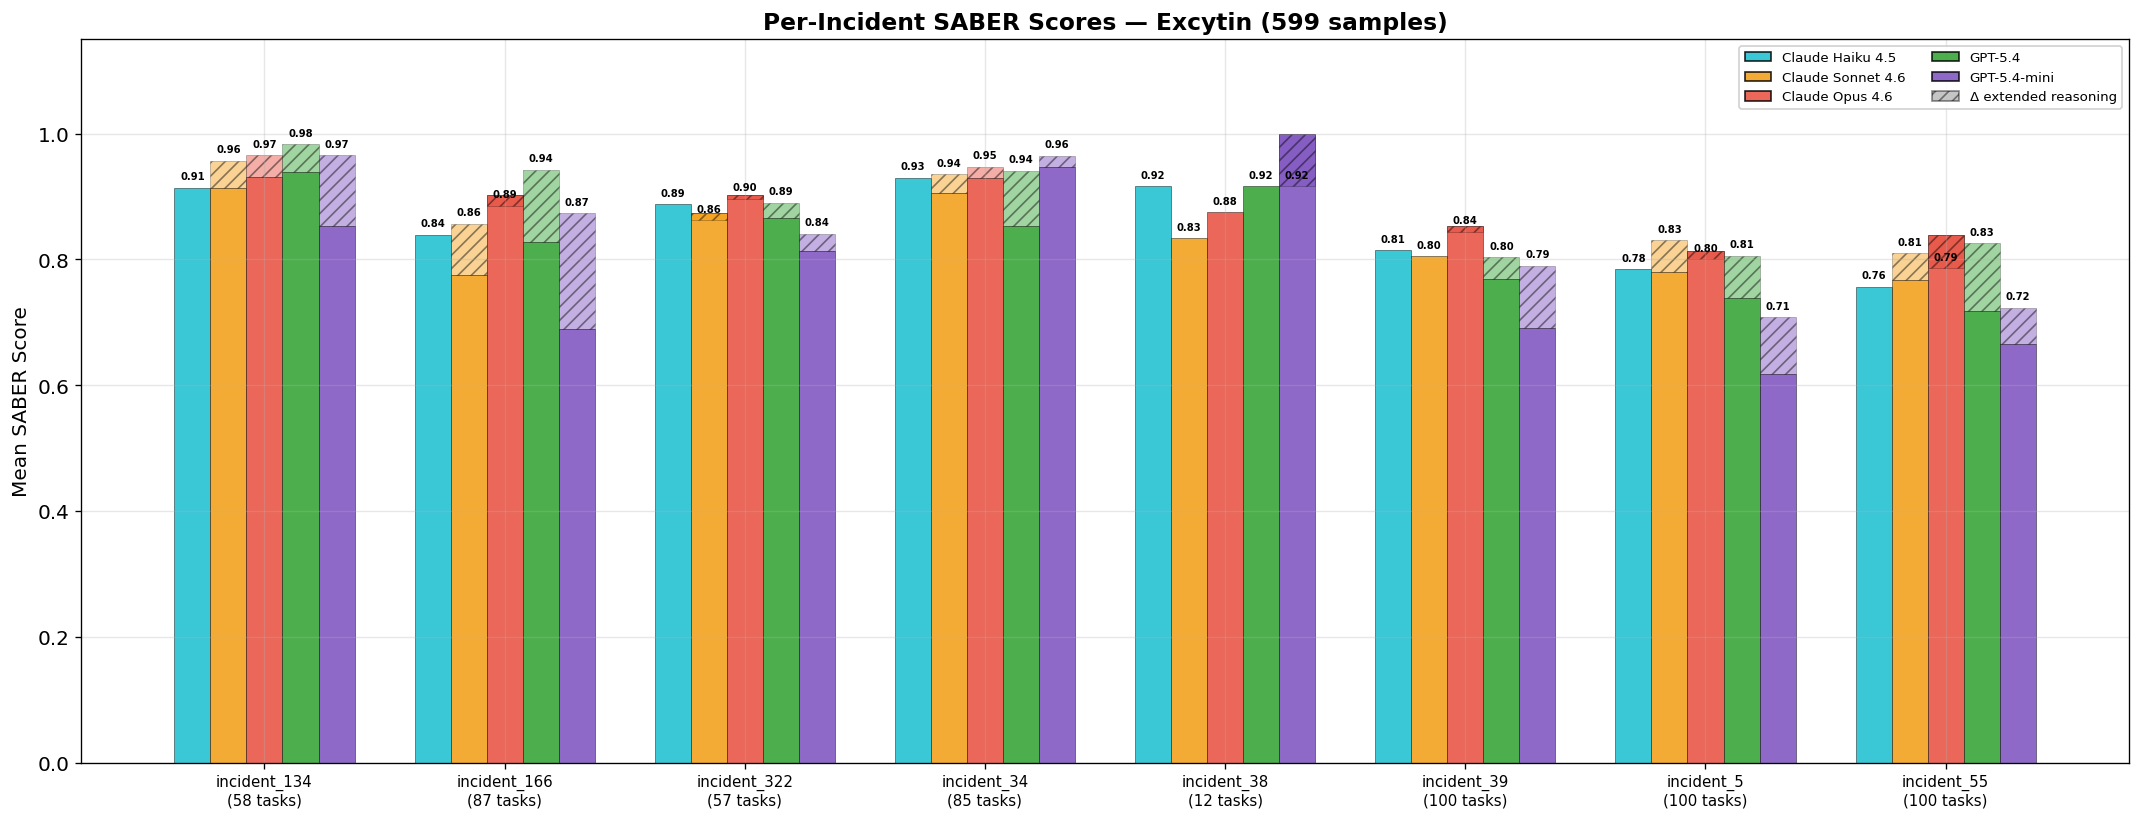

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: Per-incident grouped bar chart
# ══════════════════════════════════════════════════════════════════════════════
group_scores = samples_df.groupby(['group', 'model'])['score'].mean().unstack('model').reindex(columns=MODEL_ORDER).sort_index()
group_counts = samples_df[samples_df['model'] == MODEL_ORDER[0]].groupby('group').size()

baseline_group = pd.DataFrame()
if len(baseline_samples_df) > 0:
    baseline_group = baseline_samples_df.groupby(['group', 'model'])['score'].mean().unstack('model')
    baseline_group = baseline_group.reindex(index=group_scores.index, columns=MODEL_ORDER)

print('═══ Per-Incident Mean Scores ═══')
print(group_scores.round(4).to_string())

fig, ax = plt.subplots(figsize=(18, 7))
n_groups, n_models = len(group_scores), len(MODEL_ORDER)
bar_width = 0.15
xg = np.arange(n_groups)

for i, model in enumerate(MODEL_ORDER):
    offset = (i - n_models/2 + 0.5) * bar_width
    full_vals = group_scores[model].values
    has_base = model in no_thinking_overall and len(baseline_group) > 0 and model in baseline_group.columns

    if has_base:
        base_vals = baseline_group[model].values
        ax.bar(xg + offset, base_vals, bar_width, color=COLORS[model], edgecolor='black', linewidth=0.3, alpha=0.85)
        for xi in range(len(xg)):
            d = full_vals[xi] - base_vals[xi]
            if abs(d) > 0.001:
                ax.bar(xg[xi] + offset, abs(d), bottom=base_vals[xi] if d > 0 else full_vals[xi],
                       width=bar_width, color=COLORS[model], edgecolor='black', linewidth=0.3, alpha=0.45, hatch='///')
    else:
        ax.bar(xg + offset, full_vals, bar_width, color=COLORS[model], edgecolor='black', linewidth=0.3, alpha=0.85)

    for xi, v in zip(xg, full_vals):
        ax.text(xi + offset, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=6, fontweight='bold')

handles = [mpatches.Patch(facecolor=COLORS[m], edgecolor='black', alpha=0.85, label=m) for m in MODEL_ORDER]
handles.append(mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning'))
ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.9, ncol=2)
ax.set_xticks(xg)
ax.set_xticklabels([f'{g}\n({group_counts.get(g, "?")} tasks)' for g in group_scores.index], fontsize=9)
ax.set_ylabel('Mean SABER Score')
ax.set_title(f'Per-Incident SABER Scores — Excytin ({N_SAMPLES} samples)', fontweight='bold')
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'per_incident_scores.png', bbox_inches='tight')
plt.show()

---

## 3. Cost Analysis

### What this measures

Quantifies **total cost**, **cost per sample**, and **score-cost tradeoffs** for each model using token counts from eval logs and published API pricing.

### Charts

1. **Total Eval Cost** — absolute dollar cost of the full benchmark run (599 samples)
2. **Cost per Sample** — average cost per task (useful for budgeting)
3. **Score vs. Cost (Pareto)** — upper-left = best value; arrows show the cost of enabling reasoning

### How to read the Pareto chart

- Hollow markers = default mode (no reasoning); filled = with reasoning
- Arrows connect default → reasoning for the same model
- The Pareto frontier (upper-left envelope) shows which models dominate at each cost level

> **To add pricing for your model:** Update `PRICING` in the Configuration cell.

### Key insights (Excytin)

- **Claude Haiku 4.5** is the cheapest at $34.95 total ($0.06/sample)
- **GPT-5.4** is the most expensive at $671.79 — **19× more** than Claude Haiku 4.5
- The Pareto frontier reveals that Claude Haiku 4.5 offers the best value: near-top performance at a fraction of the cost
- Cost ordering: Claude Haiku 4.5 ($34.95) < GPT-5.4-mini ($117.78) < Claude Sonnet 4.6 ($120.48) < Claude Opus 4.6 ($441.78) < GPT-5.4 ($671.79)


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3a: Cost extraction
# ══════════════════════════════════════════════════════════════════════════════
cost_df = pd.DataFrame(extract_cost_rows(EVAL_LOGS, LOG_DIR, PRICING, N_SAMPLES)).set_index('model').reindex(MODEL_ORDER)
_baseline_rows = extract_cost_rows(NO_THINKING_LOGS, LOG_DIR, PRICING, N_SAMPLES)
baseline_cost_df = pd.DataFrame(_baseline_rows).set_index('model') if _baseline_rows else pd.DataFrame()

print('═══ Cost (with extended reasoning) ═══')
print(cost_df[['score', 'total_cost', 'cost_per_sample']].round(2).to_string())
print()
print('═══ Cost (default / no reasoning) ═══')
print(baseline_cost_df[['score', 'total_cost', 'cost_per_sample']].round(2).to_string() if len(baseline_cost_df) > 0 else '(no baseline logs configured)')

═══ Cost (with extended reasoning) ═══
                   score  total_cost  cost_per_sample
model                                                
Claude Haiku 4.5    0.84       34.95             0.06
Claude Sonnet 4.6   0.86      120.48             0.20
Claude Opus 4.6     0.86      441.78             0.74
GPT-5.4             0.88      671.79             1.12
GPT-5.4-mini        0.83      117.78             0.20

═══ Cost (default / no reasoning) ═══
                   score  total_cost  cost_per_sample
model                                                
Claude Sonnet 4.6   0.82       79.70             0.13
Claude Opus 4.6     0.87      429.37             0.72
GPT-5.4             0.80      254.77             0.43
GPT-5.4-mini        0.74       54.75             0.09


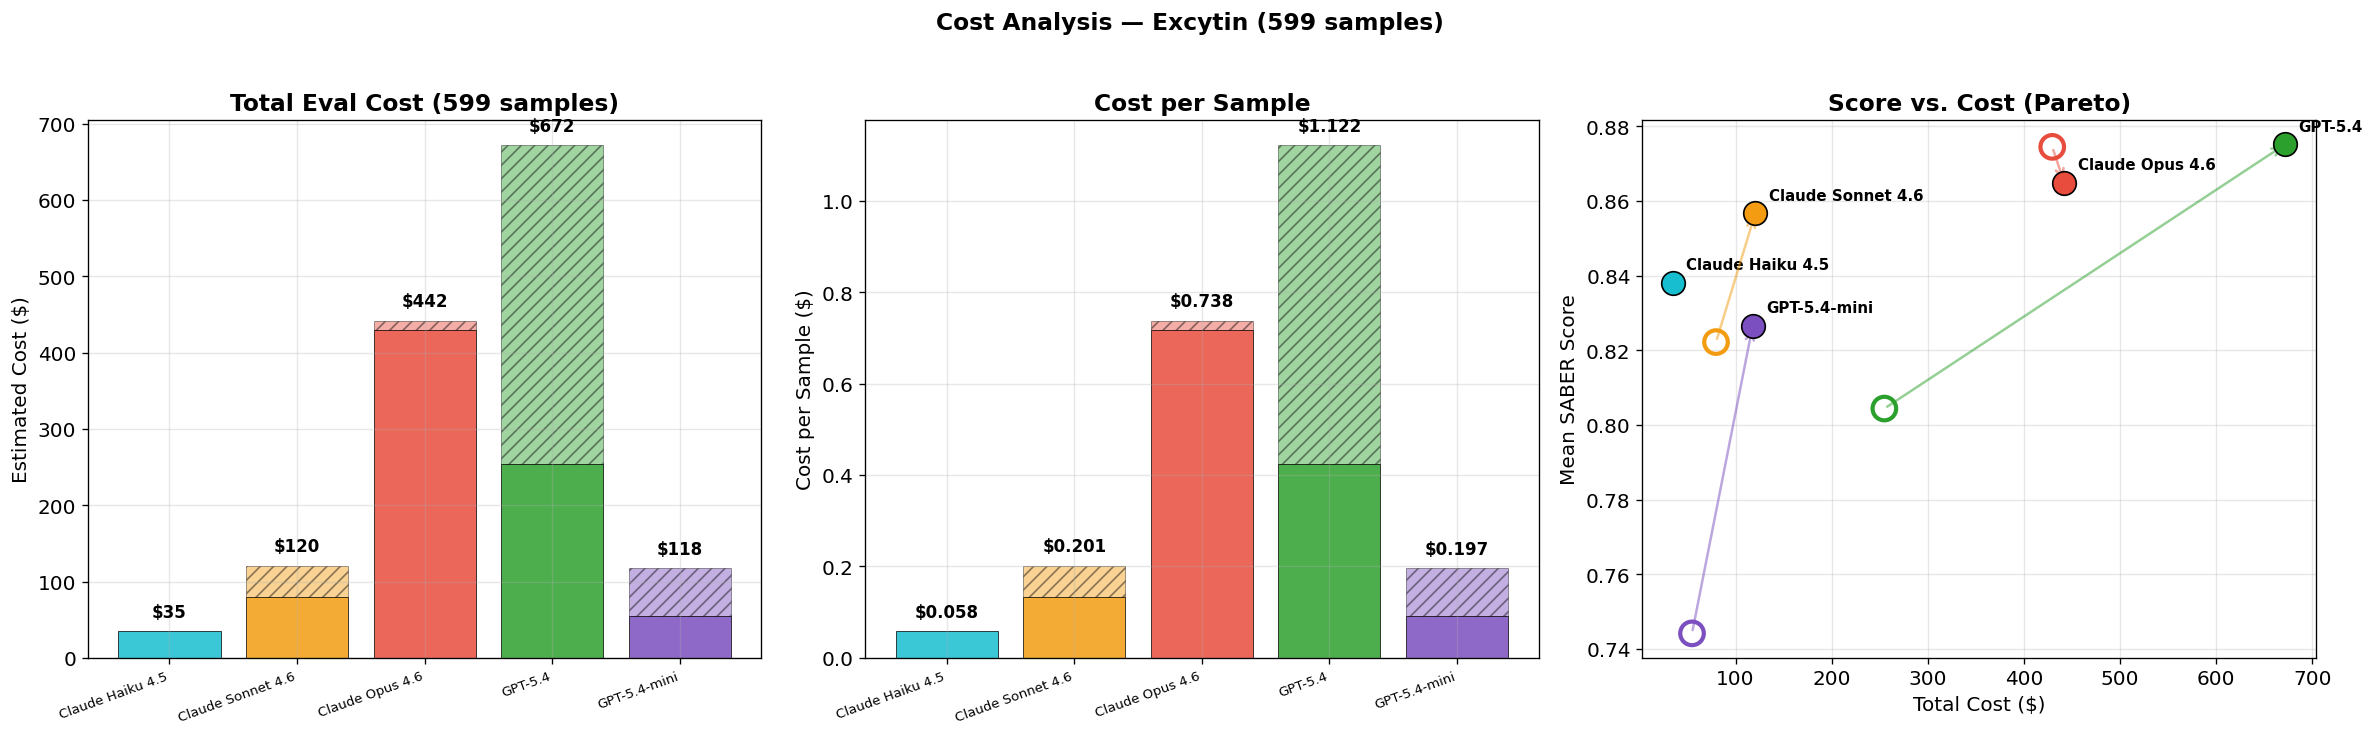

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3b: Cost visualization
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
x = np.arange(len(MODEL_ORDER))

for panel, (col, ylabel, title, fmt) in enumerate([
    ('total_cost', 'Estimated Cost ($)', f'Total Eval Cost ({N_SAMPLES} samples)', '${:.0f}'),
    ('cost_per_sample', 'Cost per Sample ($)', 'Cost per Sample', '${:.3f}'),
]):
    ax = axes[panel]
    for i, m in enumerate(MODEL_ORDER):
        val = cost_df.loc[m, col]
        if m in baseline_cost_df.index:
            base = baseline_cost_df.loc[m, col]
            ax.bar(i, base, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
            d = val - base
            ax.bar(i, abs(d), bottom=base if d > 0 else val, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
        else:
            ax.bar(i, val, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
        ax.text(i, val + cost_df[col].max()*0.02, fmt.format(val), ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=8, rotation=20, ha='right')
    ax.set_ylabel(ylabel); ax.set_title(title, fontweight='bold')

ax = axes[2]
for m in MODEL_ORDER:
    row = cost_df.loc[m]
    ax.scatter(row['total_cost'], row['score'], s=200, color=COLORS[m], edgecolor='black', linewidth=1, zorder=5)
    ax.annotate(m, (row['total_cost'], row['score']), textcoords='offset points', xytext=(8, 8), fontsize=9, fontweight='bold')
for m in baseline_cost_df.index:
    if m not in COLORS: continue
    brow = baseline_cost_df.loc[m]
    ax.scatter(brow['total_cost'], brow['score'], s=200, facecolors='none', edgecolors=COLORS[m], linewidth=2.5, zorder=4)
    ax.annotate('', xy=(cost_df.loc[m, 'total_cost'], cost_df.loc[m, 'score']), xytext=(brow['total_cost'], brow['score']),
                arrowprops=dict(arrowstyle='->', color=COLORS[m], lw=1.5, alpha=0.5))
ax.set_xlabel('Total Cost ($)'); ax.set_ylabel('Mean SABER Score'); ax.set_title('Score vs. Cost (Pareto)', fontweight='bold')

fig.suptitle(f'Cost Analysis — Excytin ({N_SAMPLES} samples)', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cost_analysis.png', bbox_inches='tight')
plt.show()

---

## 4. Token Usage Breakdown

### What this measures

Decomposes **where tokens are spent** per model: input, output, cache reads/writes, and reasoning tokens.

- **Input** — prompts, tool results, conversation history
- **Output** — model-generated text, tool calls, answers
- **Cache Read/Write** — prompt caching (reduces cost for repeated prefixes)
- **Reasoning** — internal chain-of-thought (extended thinking)

### How to read the chart

- Horizontal stacked bars show the composition of token usage per model
- **Solid segments** = default mode; **Hatched segments** = additional from extended reasoning
- Total token count and default-mode baseline annotated on the right
- Longer bars = more tokens consumed overall; Δ annotations show the reasoning overhead

### Key insights (Excytin)

- **Claude Opus 4.6** and **GPT-5.4** consume the most tokens overall, driven primarily by output tokens and reasoning
- **Claude Haiku 4.5** is the most token-efficient model — consistent with its low cost
- Cache read tokens are significant for Claude models (prompt caching reduces repeated prefix costs)
- Reasoning tokens (extended thinking) add substantial overhead for GPT-5.4 and Claude Sonnet but minimal for Haiku


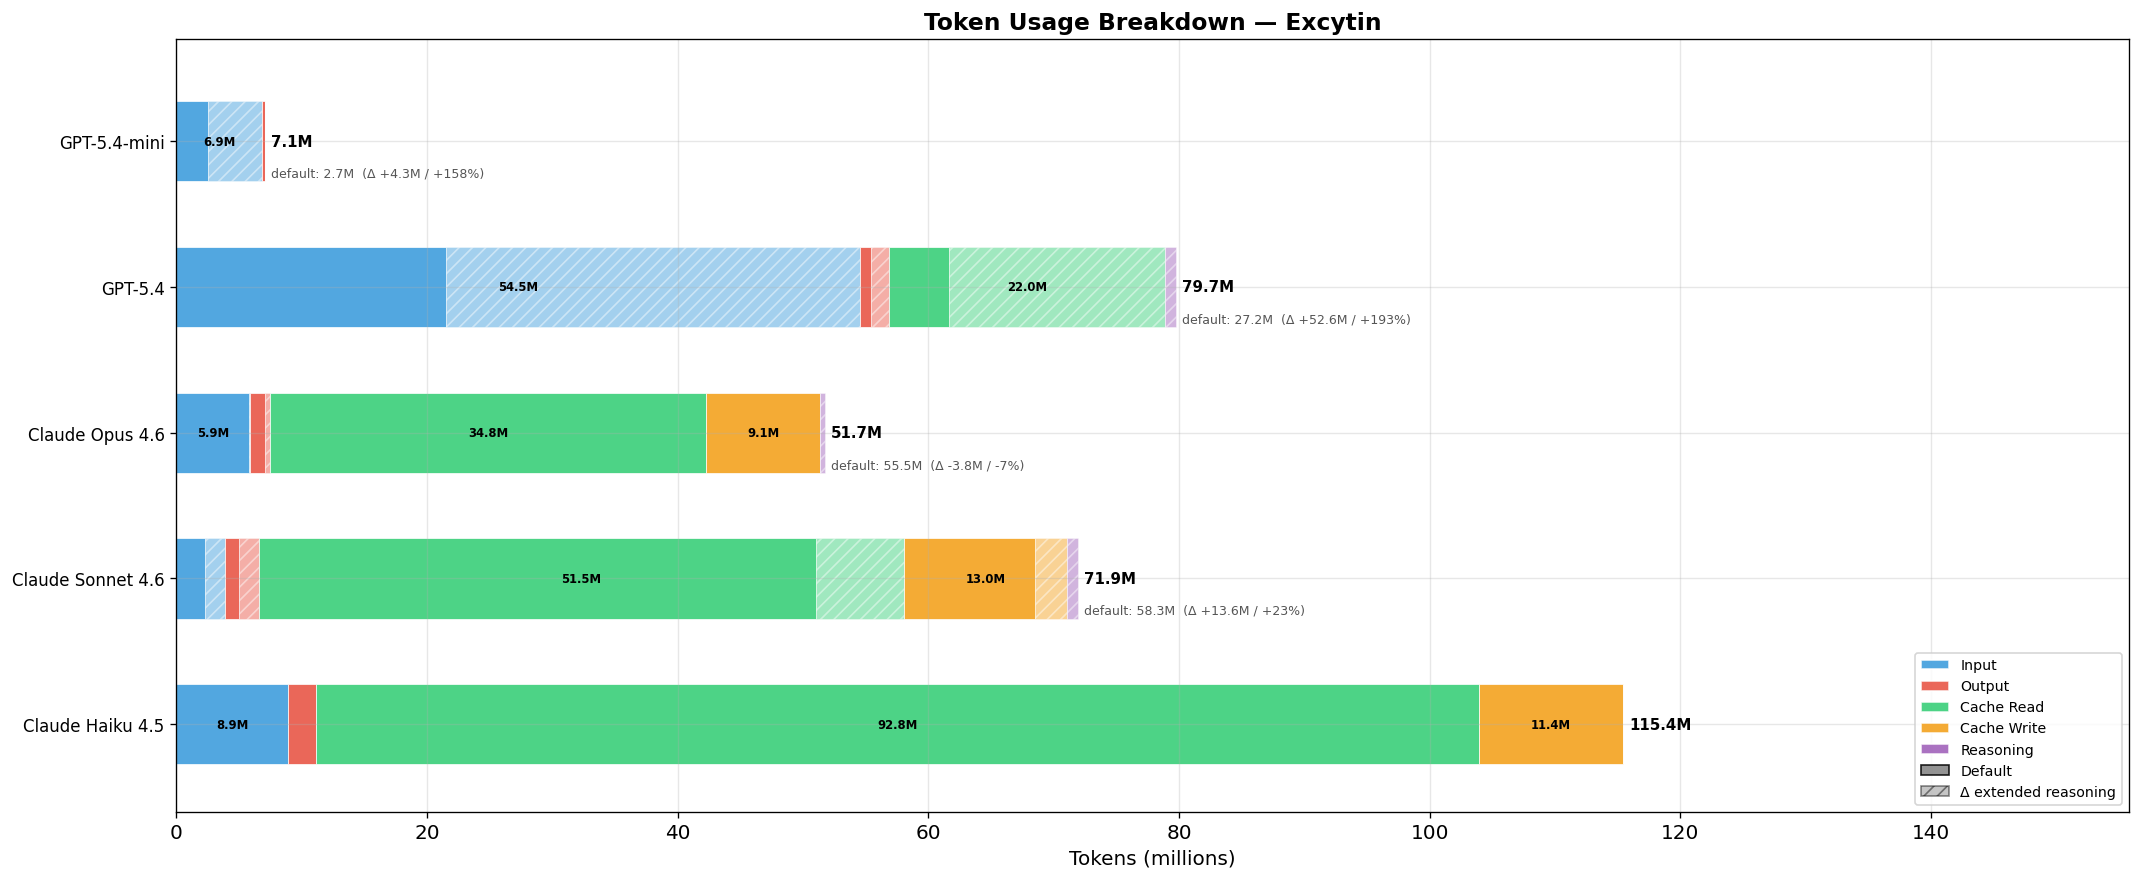

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 4: Token usage stacked horizontal bars
# ══════════════════════════════════════════════════════════════════════════════
categories = ['Input', 'Output', 'Cache Read', 'Cache Write', 'Reasoning']
cat_colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']
token_keys = ['input_tokens', 'output_tokens', 'cache_read', 'cache_write', 'reasoning_tokens']

fig, ax = plt.subplots(figsize=(18, 7.5))
bar_height = 0.55
all_totals = [sum(cost_df.loc[m][k]/1e6 for k in token_keys) for m in MODEL_ORDER]
global_max = max(all_totals)
MIN_LABEL_WIDTH = global_max * 0.05

for i, m in enumerate(MODEL_ORDER):
    row = cost_df.loc[m]
    vals = [row[k]/1e6 for k in token_keys]
    has_baseline = m in baseline_cost_df.index
    bvals = [baseline_cost_df.loc[m][k]/1e6 for k in token_keys] if has_baseline else vals

    left = 0
    for j, (rv, bv, c) in enumerate(zip(vals, bvals, cat_colors)):
        if has_baseline and rv > 0:
            solid_w = min(rv, bv)
            ax.barh(i, solid_w, left=left, height=bar_height, color=c, edgecolor='white',
                    linewidth=0.5, alpha=0.85, label=categories[j] if i == 0 else '')
            if rv - bv > 0.01:
                ax.barh(i, rv - bv, left=left + solid_w, height=bar_height, color=c,
                        edgecolor='white', linewidth=0.5, alpha=0.45, hatch='///')
        else:
            ax.barh(i, rv, left=left, height=bar_height, color=c, edgecolor='white',
                    linewidth=0.5, alpha=0.85, label=categories[j] if i == 0 else '')
        if rv >= MIN_LABEL_WIDTH:
            ax.text(left + rv/2, i, f'{rv:.1f}M', ha='center', va='center', fontsize=7, fontweight='bold')
        left += rv

    ax.text(left + 0.5, i, f'{sum(vals):.1f}M', va='center', ha='left', fontsize=9, fontweight='bold')
    if has_baseline:
        bt = sum(bvals); td = sum(vals) - bt
        ax.text(left + 0.5, i - 0.22, f'default: {bt:.1f}M  (Δ {td:+.1f}M / {td/bt*100:+.0f}%)',
                va='center', ha='left', fontsize=7.5, fontstyle='italic', color='#555')

ax.set_yticks(range(len(MODEL_ORDER))); ax.set_yticklabels(MODEL_ORDER, fontsize=10)
ax.set_xlabel('Tokens (millions)'); ax.set_title('Token Usage Breakdown — Excytin', fontweight='bold')
ax.set_xlim(right=global_max * 1.35); ax.set_ylim(-0.6, len(MODEL_ORDER) - 0.3)
legend_handles = [mpatches.Patch(facecolor=c, edgecolor='white', alpha=0.85, label=cat) for cat, c in zip(categories, cat_colors)]
legend_handles += [mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.85, label='Default'),
                   mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning')]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8.5)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'token_usage.png', bbox_inches='tight')
plt.show()

---

## 5. Cost Efficiency: Reward per Dollar

$$\text{Cost Efficiency} = \frac{\text{Mean SABER Score}}{\text{Total Cost (\$)}}$$

### What this measures

Higher = better value. The most cost-efficient model is not always the highest-scoring one — for budget-constrained deployments, this metric identifies which model delivers the most benefit per dollar.

### How to read the chart

- **Solid bars** = efficiency in default mode; **Hatched** = delta with reasoning
- Taller bars = better cost efficiency
- Note that reasoning can actually *decrease* cost efficiency if the additional cost outweighs the score improvement

### Key insights (Excytin)

- **Claude Haiku 4.5** delivers 0.0240 score per dollar — **18× more efficient** than the least efficient model
- Efficiency ranking: Claude Haiku 4.5 (0.0240) > Claude Sonnet 4.6 (0.0071) > GPT-5.4-mini (0.0070) > Claude Opus 4.6 (0.0020) > GPT-5.4 (0.0013)
- Extended reasoning can *decrease* cost efficiency if the score improvement doesn't justify the extra token cost


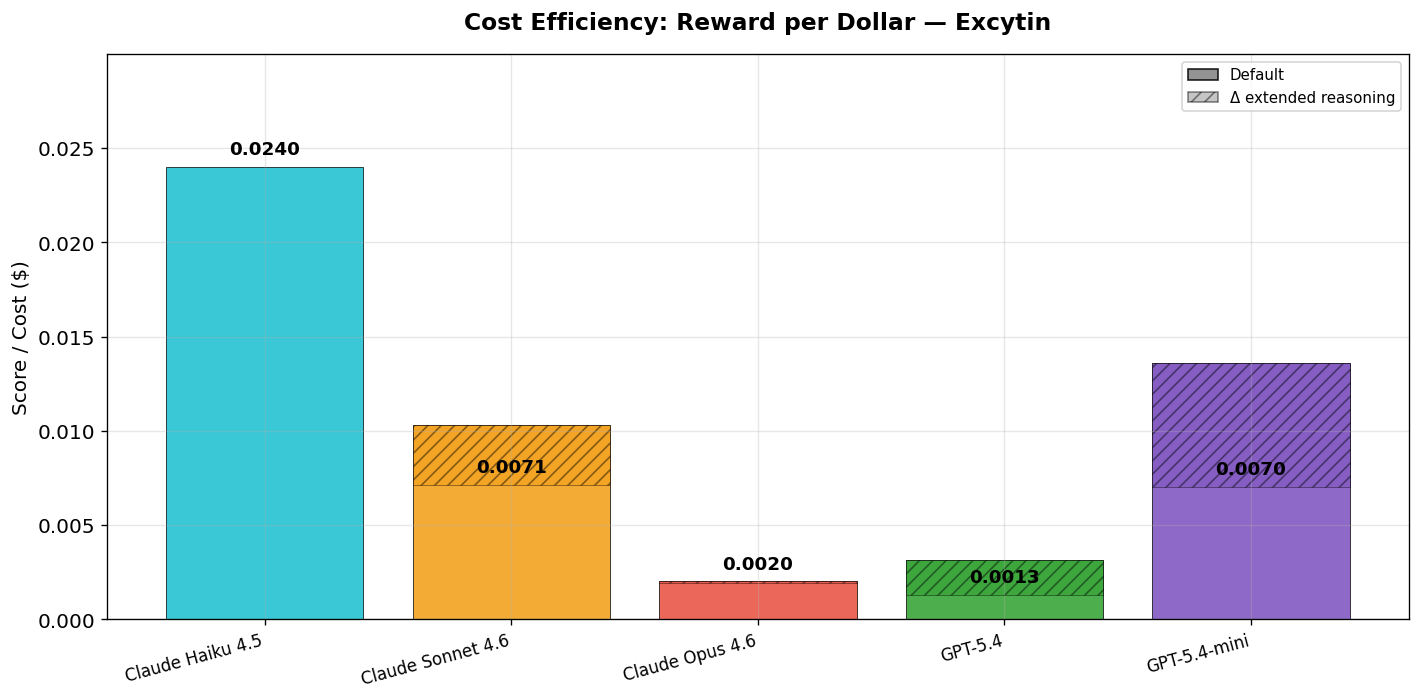

═══ Cost Efficiency Summary ═══
Model                      Score     Cost   $/sample    Score/$
────────────────────────────────────────────────────────────
Claude Haiku 4.5           0.838 $  34.95 $   0.0584    0.02398
Claude Sonnet 4.6          0.857 $ 120.48 $   0.2011    0.00711
Claude Opus 4.6            0.865 $ 441.78 $   0.7375    0.00196
GPT-5.4                    0.875 $ 671.79 $   1.1215    0.00130
GPT-5.4-mini               0.827 $ 117.78 $   0.1966    0.00702


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 5: Cost efficiency
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))
rpd = cost_df['score'] / cost_df['total_cost']
base_rpd = baseline_cost_df['score'] / baseline_cost_df['total_cost'] if len(baseline_cost_df) > 0 else pd.Series(dtype=float)

for i, m in enumerate(MODEL_ORDER):
    val = rpd[m]
    if m in base_rpd.index:
        bv = base_rpd[m]
        ax.bar(i, bv, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
        d = val - bv
        ax.bar(i, abs(d), bottom=bv if d > 0 else val, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
    else:
        ax.bar(i, val, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, val + rpd.max()*0.02, f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xticks(range(len(MODEL_ORDER))); ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Score / Cost ($)'); ax.set_title('Cost Efficiency: Reward per Dollar — Excytin', fontweight='bold', pad=15)
ax.set_ylim(0, rpd.max() * 1.25)
ax.legend(handles=[mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.85, label='Default'),
                   mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning')],
          loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cost_efficiency.png', bbox_inches='tight')
plt.show()

print('═══ Cost Efficiency Summary ═══')
print(f'{"Model":25s} {"Score":>6s} {"Cost":>8s} {"$/sample":>10s} {"Score/$":>10s}')
print('─' * 60)
for m in MODEL_ORDER:
    row = cost_df.loc[m]
    print(f'{m:25s} {row["score"]:6.3f} ${row["total_cost"]:7.2f} ${row["cost_per_sample"]:9.4f} {rpd[m]:10.5f}')

---

## 6. Sub-Task Score Breakdown

### What this measures

Excytin tasks have **submission** (final answer) + **2 checkpoints** (intermediate investigation steps) + **aggregate** scores.

- **Submission** — final answer correctness (LLM-judge or static match)
- **Checkpoints** — intermediate investigative steps (did the agent find the right logs, query the right tables, identify the right IOCs?)
- **Aggregate** — weighted combination feeding into `saber_overall`

### How to read the chart

- Grouped bars per model: blue = Submission, orange = Checkpoints, green = Aggregate
- Hatched overlays show the delta from extended reasoning
- A model with high submission but low checkpoints may be guessing — risky for production
- A model with high checkpoints but low submission investigates well but can't synthesize the final answer

### Key insights (Excytin)

- **Submission scores** (final answers) range from 0.679 to 0.756 — models are reasonably good at final answers
- **Checkpoint scores** (intermediate steps) are much lower: 0.183 to 0.224 — models often skip investigation steps
- The submission–checkpoint gap reveals that models can arrive at correct answers without following the ideal investigative process
  - **Claude Haiku 4.5**: submission=0.679, checkpoint_avg=0.203, aggregate=0.838
  - **Claude Sonnet 4.6**: submission=0.705, checkpoint_avg=0.196, aggregate=0.857
  - **Claude Opus 4.6**: submission=0.756, checkpoint_avg=0.183, aggregate=0.865
  - **GPT-5.4**: submission=0.683, checkpoint_avg=0.224, aggregate=0.875
  - **GPT-5.4-mini**: submission=0.718, checkpoint_avg=0.205, aggregate=0.827


═══ Sub-Task Mean Scores ═══
category           Submission  Checkpoints  Aggregate
model                                                
Claude Haiku 4.5       0.6795       0.2374     0.8381
Claude Sonnet 4.6      0.7045       0.2185     0.8567
Claude Opus 4.6        0.7563       0.2028     0.8649
GPT-5.4                0.6828       0.2709     0.8752
GPT-5.4-mini           0.7179       0.2489     0.8265


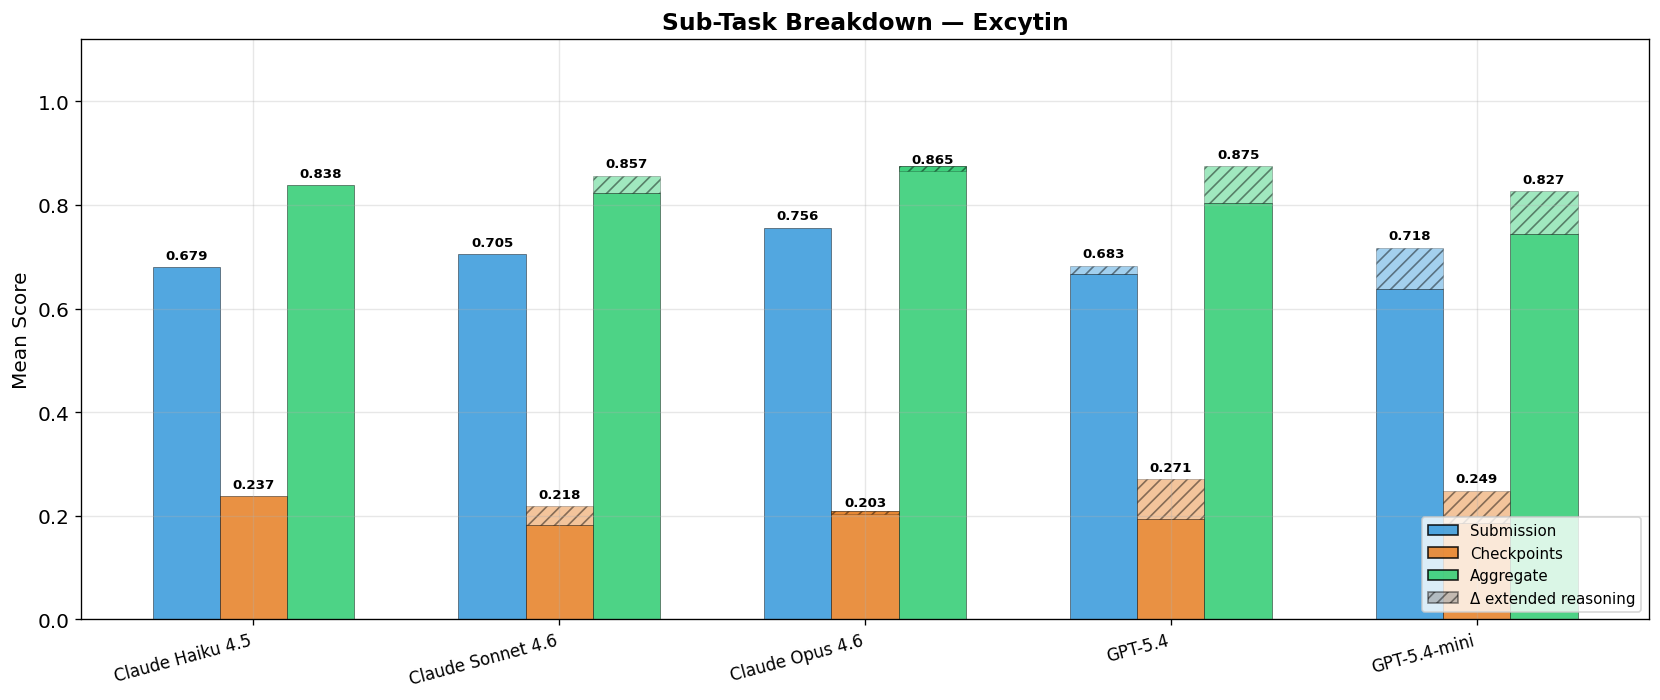

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 6: Sub-task breakdown
# ══════════════════════════════════════════════════════════════════════════════
subtasks_df['category'] = subtasks_df['score_type'].apply(classify_score_type)
cat_means = subtasks_df.groupby(['model', 'category'])['score'].mean().unstack('category')
available_cats = [c for c in ['Submission', 'Checkpoints', 'Aggregate'] if c in cat_means.columns]
cat_means = cat_means.reindex(MODEL_ORDER)[available_cats]

baseline_cat_means = pd.DataFrame()
if len(baseline_subtasks_df) > 0:
    baseline_subtasks_df['category'] = baseline_subtasks_df['score_type'].apply(classify_score_type)
    baseline_cat_means = baseline_subtasks_df.groupby(['model', 'category'])['score'].mean().unstack('category')
    baseline_cat_means = baseline_cat_means.reindex(columns=available_cats)

print('═══ Sub-Task Mean Scores ═══')
print(cat_means.round(4).to_string())

fig, ax = plt.subplots(figsize=(14, 6))
cat_plot_colors = ['#3498DB', '#E67E22', '#2ECC71'][:len(available_cats)]
x = np.arange(len(MODEL_ORDER))
bar_width = 0.22
for j, (cat, color) in enumerate(zip(available_cats, cat_plot_colors)):
    offset = (j - len(available_cats)/2 + 0.5) * bar_width
    for i, m in enumerate(MODEL_ORDER):
        fv = cat_means.loc[m, cat]
        has_base = (len(baseline_cat_means) > 0 and m in baseline_cat_means.index
                    and cat in baseline_cat_means.columns and not pd.isna(baseline_cat_means.loc[m, cat]))
        if has_base:
            bv = baseline_cat_means.loc[m, cat]
            ax.bar(x[i]+offset, bv, bar_width, color=color, edgecolor='black', linewidth=0.3, alpha=0.85)
            d = fv - bv
            if abs(d) > 0.001:
                ax.bar(x[i]+offset, abs(d), bottom=bv if d > 0 else fv, width=bar_width, color=color,
                       edgecolor='black', linewidth=0.3, alpha=0.45, hatch='///')
        else:
            ax.bar(x[i]+offset, fv, bar_width, color=color, edgecolor='black', linewidth=0.3, alpha=0.85)
        ax.text(x[i]+offset, fv+0.01, f'{fv:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

handles = [mpatches.Patch(facecolor=c, edgecolor='black', alpha=0.85, label=cat) for cat, c in zip(available_cats, cat_plot_colors)]
handles.append(mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning'))
ax.legend(handles=handles, fontsize=9, loc='lower right')
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Mean Score'); ax.set_title('Sub-Task Breakdown — Excytin', fontweight='bold'); ax.set_ylim(0, 1.12)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'subtask_breakdown.png', bbox_inches='tight')
plt.show()

---

## 7. Checkpoint Score Distributions

### What this measures

Violin plots showing the **full distribution** of checkpoint scores per model. Wide regions = many samples clustered at that score level.

### How to read the chart

- **Bimodal distributions** (two peaks at 0 and 1) = model either nails the checkpoint or misses completely — pass/fail in nature
- **Tight distributions** = consistent performance
- Mean (μ) and sample count (n) annotated above each violin
- The dashed line shows the median; the solid line shows the mean

### Key insights (Excytin)

- Checkpoint distributions are heavily **bimodal** — models either pass a checkpoint completely or miss it entirely
- Most checkpoints cluster near 0, with a smaller peak near 1.0 — indicating pass/fail checkpoint design
- **GPT-5.4** has the highest checkpoint means across both checkpoint types, consistent with its thorough investigation style
- **Claude Opus 4.6** has the most samples at exactly 0, suggesting it skips intermediate steps more aggressively


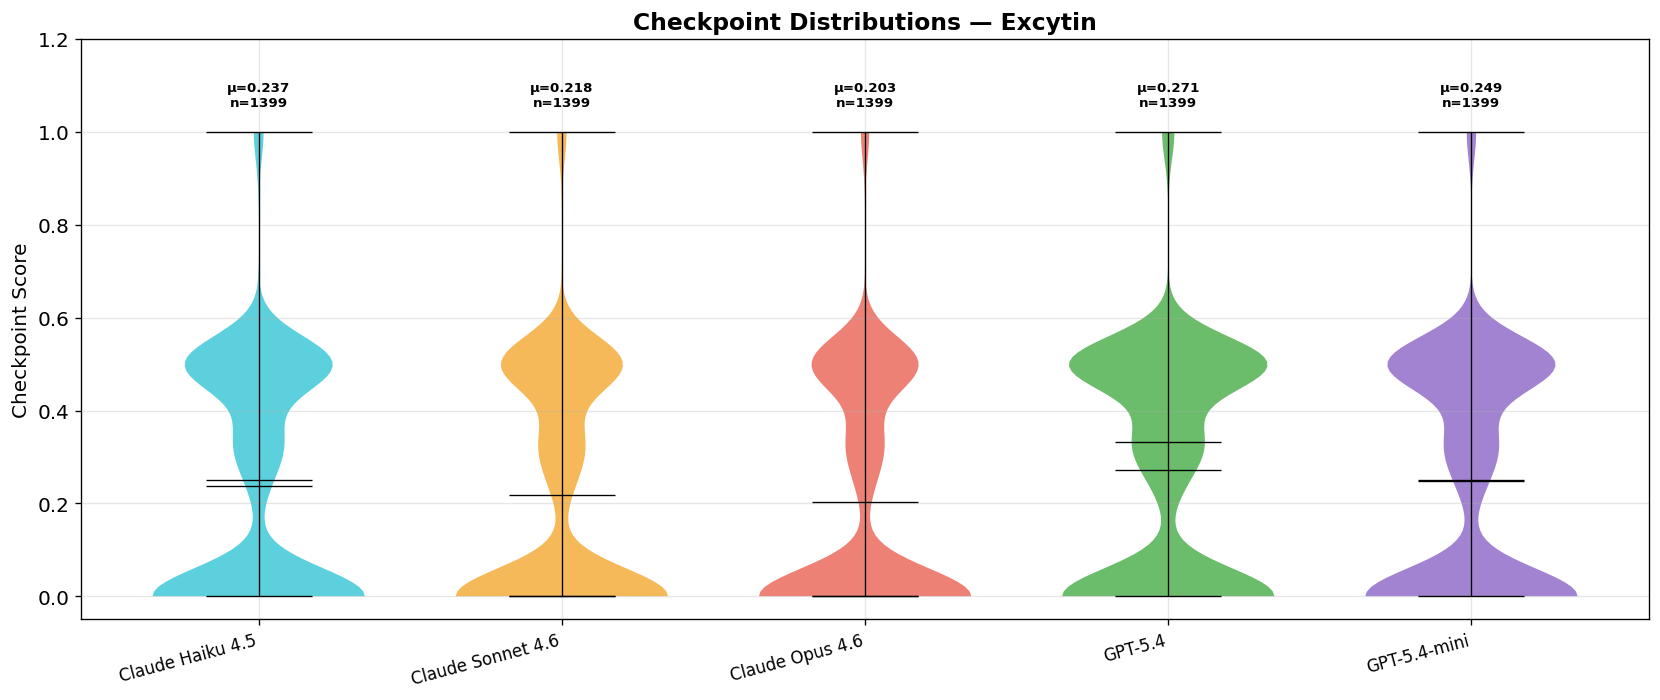

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 7: Checkpoint distributions (violin)
# ══════════════════════════════════════════════════════════════════════════════
checkpoint_df = subtasks_df[subtasks_df['score_type'].str.startswith('checkpoint')].copy()
fig, ax = plt.subplots(figsize=(14, 6))
positions, tick_labels = [], []
for i, model in enumerate(MODEL_ORDER):
    data = checkpoint_df[checkpoint_df['model'] == model]['score'].values
    if len(data) == 0: continue
    vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
    for pc in vp['bodies']: pc.set_facecolor(COLORS[model]); pc.set_alpha(0.7)
    for part in ('cmaxes','cmins','cbars','cmeans','cmedians'):
        if part in vp: vp[part].set_edgecolor('black'); vp[part].set_linewidth(0.8)
    ax.text(i, 1.05, f'μ={np.mean(data):.3f}\nn={len(data)}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    positions.append(i); tick_labels.append(model)

ax.set_xticks(positions); ax.set_xticklabels(tick_labels, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Checkpoint Score'); ax.set_title('Checkpoint Distributions — Excytin', fontweight='bold')
ax.set_ylim(-0.05, 1.2)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'checkpoint_distributions.png', bbox_inches='tight')
plt.show()

---

## 8. Submission vs. Checkpoint Gap Analysis (Excytin-Specific)

### What this measures

This heatmap is **unique to Excytin** — it shows the gap between submission and checkpoint scores **per incident per model**.

- **Red (positive):** Submission > Checkpoints — model guesses correctly without thorough investigation
- **Green (negative):** Checkpoints > Submission — model investigates well but fails to synthesize the answer
- **Yellow (≈0):** Aligned — investigation quality matches answer quality

Models with consistently positive gaps may be unreliable in production — they could be "guessing right" on benchmarks.

### Key insights (Excytin)

- All models show a **large positive gap** (submission >> checkpoint) — they answer correctly without completing all investigation steps
- Gap ranges from 0.459 to 0.573
- This suggests models may be using shortcuts or prior knowledge rather than following the intended investigation path
  - **Claude Haiku 4.5**: submission=0.679, checkpoint=0.203, gap=0.476
  - **Claude Sonnet 4.6**: submission=0.705, checkpoint=0.196, gap=0.508
  - **Claude Opus 4.6**: submission=0.756, checkpoint=0.183, gap=0.573
  - **GPT-5.4**: submission=0.683, checkpoint=0.224, gap=0.459
  - **GPT-5.4-mini**: submission=0.718, checkpoint=0.205, gap=0.513


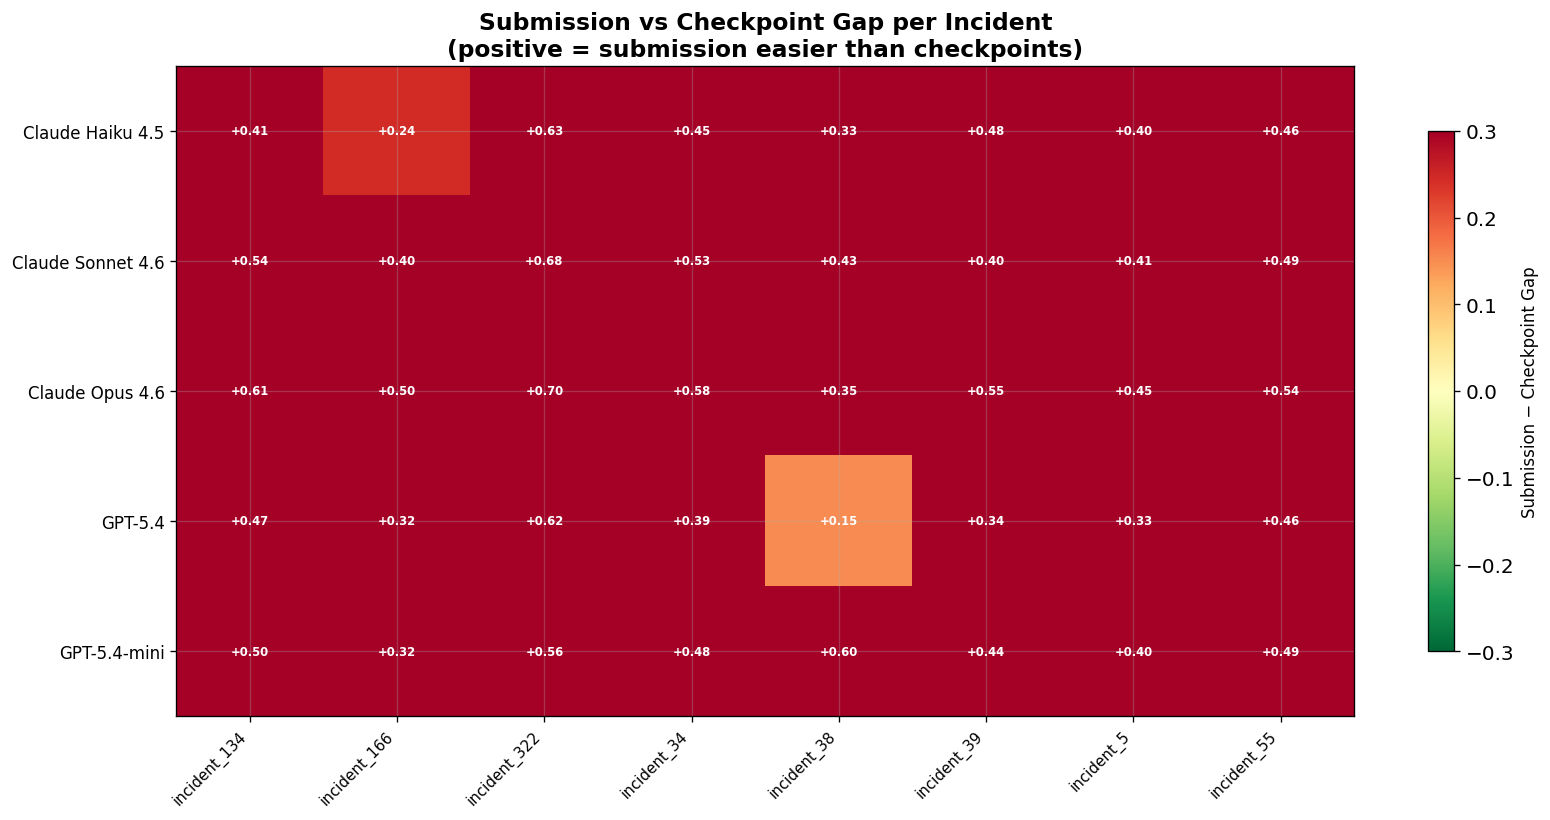

═══ Average Submission–Checkpoint Gap per Model ═══
  Claude Haiku 4.5           avg gap = +0.4256
  Claude Sonnet 4.6          avg gap = +0.4857
  Claude Opus 4.6            avg gap = +0.5346
  GPT-5.4                    avg gap = +0.3850
  GPT-5.4-mini               avg gap = +0.4749


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 8 (EXCYTIN-SPECIFIC): Submission vs checkpoint gap heatmap
# ══════════════════════════════════════════════════════════════════════════════
sub_means = subtasks_df[subtasks_df['category'] == 'Submission'].groupby(['group', 'model'])['score'].mean().unstack('model').reindex(columns=MODEL_ORDER)
cp_means = subtasks_df[subtasks_df['category'] == 'Checkpoints'].groupby(['group', 'model'])['score'].mean().unstack('model').reindex(columns=MODEL_ORDER)
gap = sub_means - cp_means

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(gap.T.values, cmap='RdYlGn_r', aspect='auto', vmin=-0.3, vmax=0.3)
ax.set_xticks(range(len(gap.index)))
ax.set_xticklabels(gap.index, fontsize=9, rotation=45, ha='right')
ax.set_yticks(range(len(MODEL_ORDER)))
ax.set_yticklabels(MODEL_ORDER, fontsize=10)

for i, model in enumerate(MODEL_ORDER):
    for j, inc in enumerate(gap.index):
        val = gap.loc[inc, model]
        if not np.isnan(val):
            ax.text(j, i, f'{val:+.2f}', ha='center', va='center', fontsize=7,
                    fontweight='bold', color='white' if abs(val) > 0.15 else 'black')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Submission − Checkpoint Gap', fontsize=10)
ax.set_title('Submission vs Checkpoint Gap per Incident\n(positive = submission easier than checkpoints)', fontweight='bold')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'submission_checkpoint_gap.png', bbox_inches='tight')
plt.show()

print('═══ Average Submission–Checkpoint Gap per Model ═══')
for m in MODEL_ORDER:
    print(f'  {m:25s}  avg gap = {gap[m].mean():+.4f}')

---

## 9. Agent Trajectory Analysis

### What this measures

Analyses 9–13 examine the **behavioral patterns** of the agent — how many tool calls it makes, which tools it uses, how efficiently it spends time, and whether more effort correlates with better scores.

This cell loads per-sample trajectory data: steps (assistant turns), tool calls, and timing from each eval log using inspect_ai's typed log API.

### Key metrics loaded

- **n_tool_calls** — actual tool invocations (capped at TOOL_CALL_LIMIT in practice)
- **n_steps** — assistant message turns (can exceed tool call limit since some turns don't use tools)
- **tool_counts** — per-tool breakdown (e.g., bash vs. python)
- **total_time** — wall-clock seconds per sample

### Key insights

- **2,995 trajectory samples** loaded across 5 models (599 per model).
- Claude Haiku 4.5 uses the most tool calls on average (**15.3 ± 7.1**), while Claude Opus 4.6 is the most economical (**9.4 ± 6.1**) — suggesting Opus solves tasks with fewer interactions despite having the highest or near-highest score.
- GPT-5.4 and GPT-5.4-mini sit in the middle (~10–11 calls), while Sonnet uses ~11.
- Only two tools are observed: `bash` and `python`, consistent with Excytin's SQL investigation workflow.

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAJECTORY DATA LOADING — Per-sample steps, tool calls, and timing
# ══════════════════════════════════════════════════════════════════════════════
from collections import Counter

traj_df = load_trajectory_data(EVAL_LOGS, LOG_DIR, MODEL_ORDER, group_fn=GROUP_FN)

# Normalize tool names to lowercase (e.g. "Bash" and "bash" → "bash")
traj_df['tool_counts'] = traj_df['tool_counts'].apply(
    lambda d: dict(Counter({k.lower(): v for k, v in d.items()}))
)

# Flatten tool_counts dicts into separate columns per tool
all_tools = sorted({t for tc in traj_df['tool_counts'] for t in tc})
for tool in all_tools:
    traj_df[f'tool_{tool}'] = traj_df['tool_counts'].apply(lambda d, t=tool: d.get(t, 0))

print(f'✓ Loaded trajectory data: {len(traj_df)} samples × {traj_df["model"].nunique()} models')
print(f'  Tools observed: {all_tools}')
print()
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m]
    print(f'  {m:25s}  steps={mdf.n_steps.mean():.1f}±{mdf.n_steps.std():.1f}  '
          f'tool_calls={mdf.n_tool_calls.mean():.1f}±{mdf.n_tool_calls.std():.1f}  '
          f'time={mdf.total_time.mean():.0f}s±{mdf.total_time.std():.0f}s')

✓ Loaded trajectory data: 2995 samples × 5 models
  Tools observed: ['bash', 'python']

  Claude Haiku 4.5           steps=16.2±7.1  tool_calls=15.3±7.1  time=115s±48s
  Claude Sonnet 4.6          steps=8.1±4.6  tool_calls=11.1±7.6  time=108s±92s
  Claude Opus 4.6            steps=7.7±5.1  tool_calls=9.4±6.1  time=86s±152s
  GPT-5.4                    steps=10.2±4.9  tool_calls=10.9±5.6  time=743s±950s
  GPT-5.4-mini               steps=10.3±5.8  tool_calls=10.2±6.2  time=149s±98s


### 9a. Mean Score vs. Tool-Call Limit — What's the Optimal Budget?

For each tool-call limit N on the x-axis, compute the mean score across **all samples**, where samples that needed > N tool calls get score 0 (wouldn't have finished under that budget). This shows where returns from allowing more tool calls diminish.

- **Steeper early rise** = model solves many tasks quickly (efficient)
- **Plateau** = increasing the budget further yields diminishing returns
- Curves converge to each model's actual mean score at the real tool-call cap

### Key insights

- All five models reach **95% of their final score** by tool-call limit 23–25 (out of a cap of 25), meaning very few tasks require the full budget to succeed.
- Curves rise steeply between limits 3–12, then flatten — most tasks are solved in roughly **5–15 tool calls**.
- GPT-5.4 converges slightly earlier (95% at 23 calls) while the Claude family needs the full 25, suggesting GPT-5.4 has a tighter effort distribution with fewer long-tail tasks.
- The checkpoint panel shows the same pattern but with finer granularity, confirming that intermediate progress also accumulates quickly in the first ~10 calls.

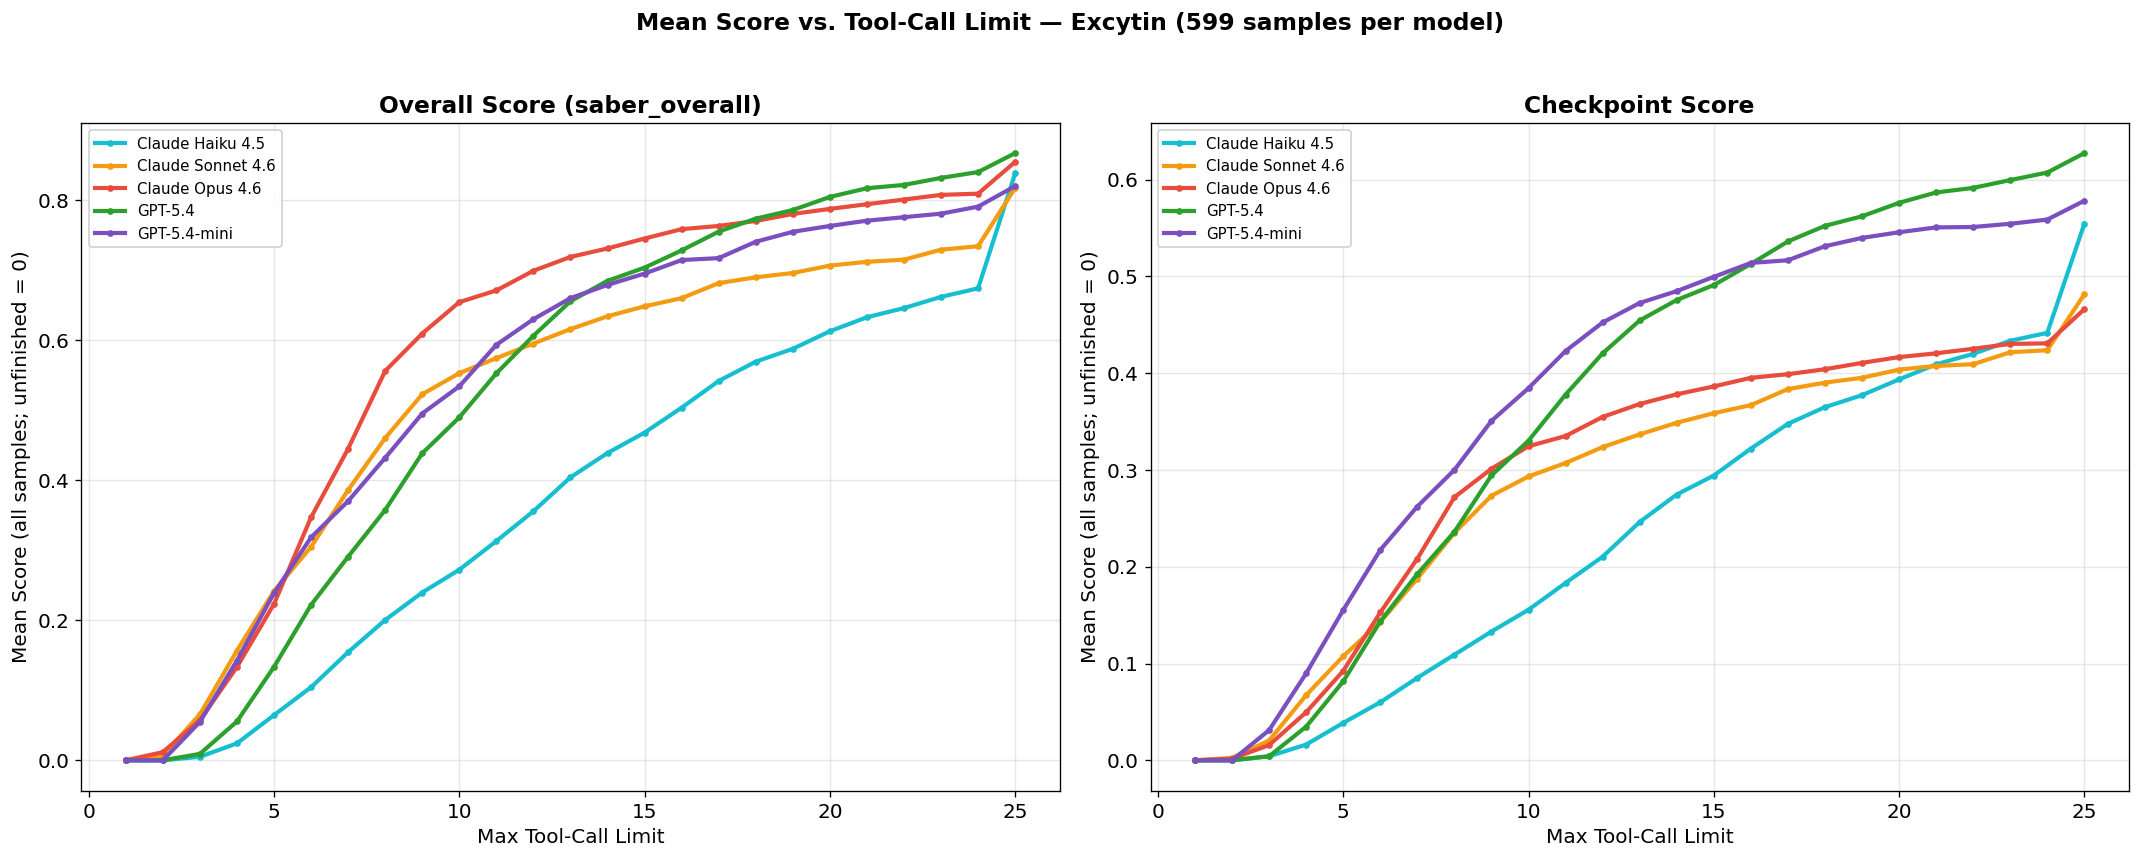

═══ Tool-Call Limit Analysis (overall score) ═══
Tool-call limit at which model reaches 95% of its full score:

  Claude Haiku 4.5           95% at 25 calls  (100% of samples done, full=0.8381)
  Claude Sonnet 4.6          95% at 25 calls  (95% of samples done, full=0.8567)
  Claude Opus 4.6            95% at 25 calls  (99% of samples done, full=0.8649)
  GPT-5.4                    95% at 23 calls  (95% of samples done, full=0.8752)
  GPT-5.4-mini               95% at 24 calls  (94% of samples done, full=0.8265)


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 9a: Mean Score vs. Max Tool-Call Limit
# ══════════════════════════════════════════════════════════════════════════════

step_lookup = traj_df[['model', 'sample_id', 'n_tool_calls']].copy()
merged = subtasks_df.merge(step_lookup, on=['model', 'sample_id'], how='inner')
if 'category' not in merged.columns:
    merged['category'] = merged['score_type'].apply(classify_score_type)

call_limits = list(range(1, TOOL_CALL_LIMIT + 1))

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

for ax, (score_label, score_src) in zip(axes, [
    ('Overall Score (saber_overall)', 'overall'),
    ('Checkpoint Score', 'checkpoint'),
]):
    for m in MODEL_ORDER:
        if score_src == 'overall':
            mdf = traj_df[traj_df['model'] == m].copy()
            total_samples = len(mdf)
        else:
            mdf = merged[(merged['model'] == m) & (merged['category'] == 'Checkpoints')].copy()
            if mdf.empty:
                continue
            total_samples = mdf['sample_id'].nunique()

        means = []
        for limit in call_limits:
            completed = mdf[mdf['n_tool_calls'] <= limit]
            avg = completed['score'].sum() / total_samples if total_samples > 0 else 0
            means.append(avg)

        ax.plot(call_limits, means, color=COLORS[m],
                linewidth=2.5, marker='o', markersize=3, label=m, zorder=5)

    ax.set_xlabel('Max Tool-Call Limit')
    ax.set_ylabel('Mean Score (all samples; unfinished = 0)')
    ax.set_title(score_label, fontweight='bold')
    ax.legend(fontsize=9, loc='best', framealpha=0.9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(f'Mean Score vs. Tool-Call Limit — {DOMAIN_NAME} ({N_SAMPLES} samples per model)',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'score_vs_tool_call_limit.png', bbox_inches='tight')
plt.show()

# Summary: at what tool-call limit does each model reach 95% of its final score?
print('═══ Tool-Call Limit Analysis (overall score) ═══')
print('Tool-call limit at which model reaches 95% of its full score:\n')
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m]
    total = len(mdf)
    full_score = mdf['score'].mean()
    target = full_score * 0.95
    limit_95 = TOOL_CALL_LIMIT
    for limit in call_limits:
        avg = mdf[mdf['n_tool_calls'] <= limit]['score'].sum() / total
        if avg >= target:
            limit_95 = limit
            break
    pct_done = len(mdf[mdf['n_tool_calls'] <= limit_95]) / total
    print(f'  {m:25s}  95% at {limit_95:2d} calls  '
          f'({pct_done:.0%} of samples done, full={full_score:.4f})')

### 9b. Effort Distribution per Model

How many tool calls and steps does each model use per task? Violin plots show the full distribution.

- **Narrow, low** = efficient (solves tasks quickly)
- **Wide, high** = variable or struggling (many tasks need lots of calls)
- **Long upper tail** = some tasks cause the agent to max out its tool-call budget

### Key insights

- **Claude Haiku 4.5** has the widest distribution and highest mean (μ=15.3 tool calls) — it makes noticeably more calls than other models, often saturating the 25-call budget. This aligns with Haiku being a smaller model that needs more iterative attempts.
- **Claude Opus 4.6** is the most focused (μ=9.4) with a narrow distribution, indicating it solves most tasks decisively in fewer turns.
- GPT-5.4 (μ=10.9) and GPT-5.4-mini (μ=10.2) show similar distributions to Sonnet (μ=11.1), all concentrated in the 5–15 call range.
- All models show a visible upper cluster at 25 calls, representing tasks where the agent hit the tool-call limit — Haiku has the largest such cluster (visible in the upper tail density).

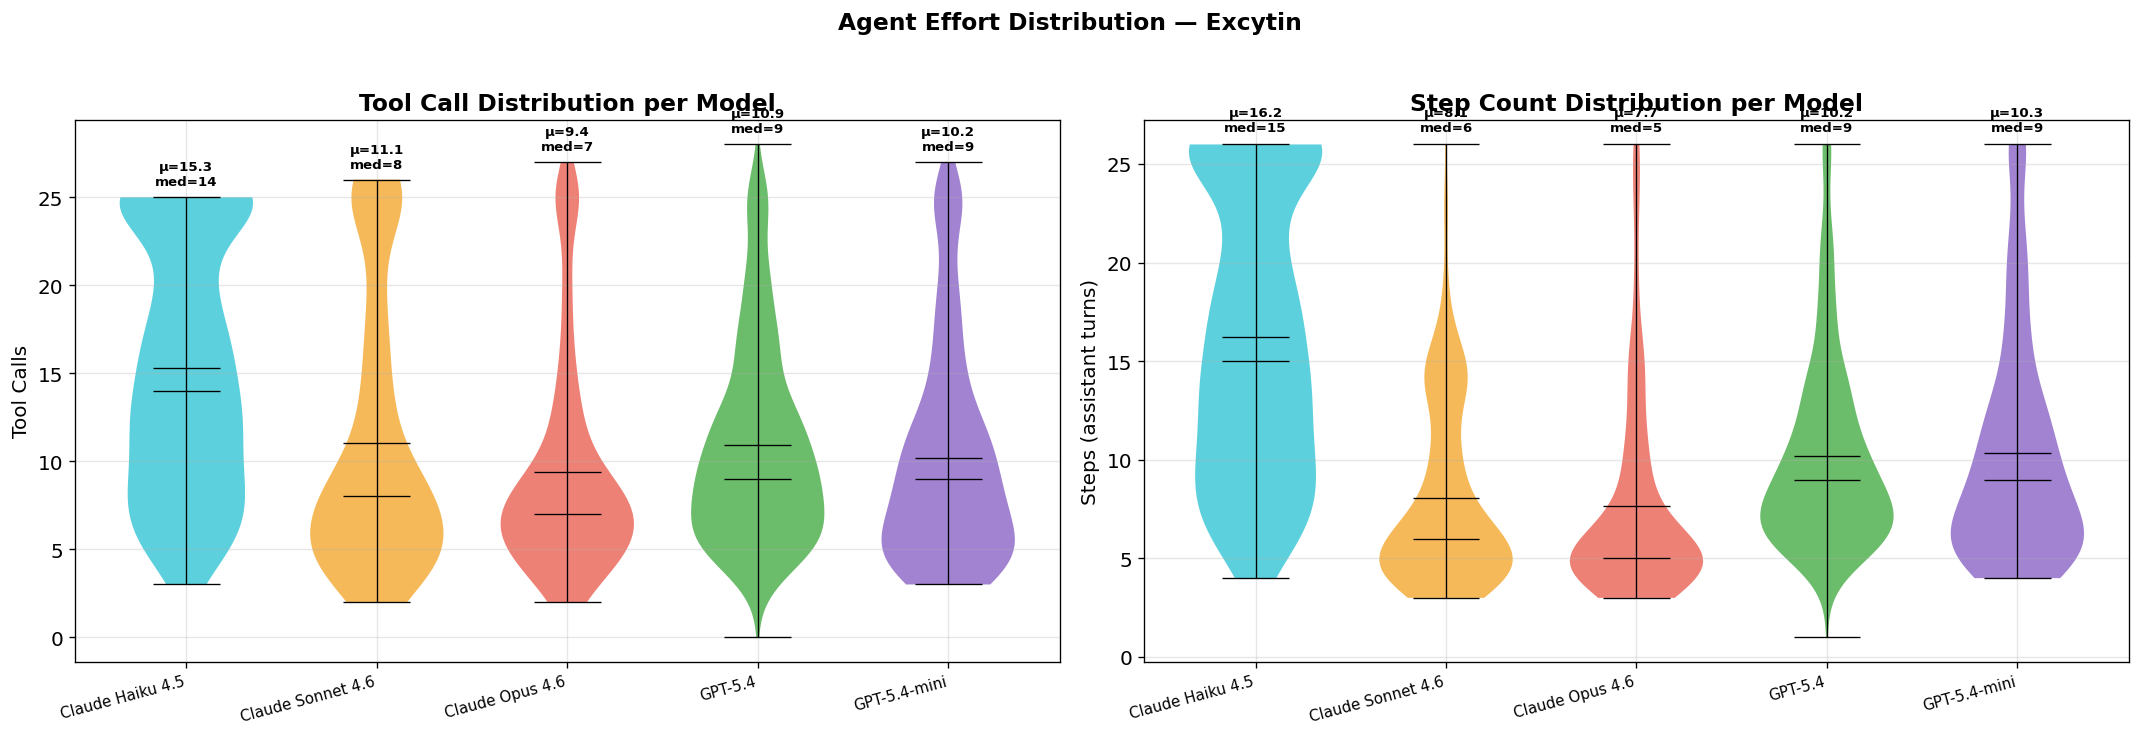

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 9b: Tool call & step count distribution (violin + box)
# ══════════════════════════════════════════════════════════════════════════════
if N_SAMPLES < 3:
    print(f'⚠ Only {N_SAMPLES} sample(s) per model — skipping violin plots (need ≥3 for meaningful distributions)')
    print()
    for m in MODEL_ORDER:
        mdf = traj_df[traj_df['model'] == m]
        print(f'  {m:25s}  tool_calls={mdf["n_tool_calls"].values}  steps={mdf["n_steps"].values}')
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Panel 1 (primary): Tool call distribution
    ax = axes[0]
    for i, m in enumerate(MODEL_ORDER):
        data = traj_df[traj_df['model'] == m]['n_tool_calls'].values
        vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
        for pc in vp['bodies']:
            pc.set_facecolor(COLORS[m])
            pc.set_alpha(0.7)
        for part in ('cmaxes', 'cmins', 'cbars', 'cmeans', 'cmedians'):
            if part in vp:
                vp[part].set_edgecolor('black')
                vp[part].set_linewidth(0.8)
        ax.text(i, data.max() + 0.5, f'μ={np.mean(data):.1f}\nmed={np.median(data):.0f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
    ax.set_ylabel('Tool Calls')
    ax.set_title('Tool Call Distribution per Model', fontweight='bold')

    # Panel 2 (secondary): Step count distribution
    ax = axes[1]
    for i, m in enumerate(MODEL_ORDER):
        data = traj_df[traj_df['model'] == m]['n_steps'].values
        vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
        for pc in vp['bodies']:
            pc.set_facecolor(COLORS[m])
            pc.set_alpha(0.7)
        for part in ('cmaxes', 'cmins', 'cbars', 'cmeans', 'cmedians'):
            if part in vp:
                vp[part].set_edgecolor('black')
                vp[part].set_linewidth(0.8)
        ax.text(i, data.max() + 0.5, f'μ={np.mean(data):.1f}\nmed={np.median(data):.0f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
    ax.set_ylabel('Steps (assistant turns)')
    ax.set_title('Step Count Distribution per Model', fontweight='bold')

    fig.suptitle(f'Agent Effort Distribution — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / 'effort_distributions.png', bbox_inches='tight')
    plt.show()

---

## 10. Tool Usage Analysis

### What this measures

How each model allocates its tool calls across available tools. The agent typically has access to `bash` and `python` (and domain-specific tools in other domains).

### How to read the chart

- **Left panel**: Mean tool calls per tool per model — shows tool preference
- **Right panel**: Tool call ratio (fraction of calls going to each tool) — normalizes for varying total effort

### Key insights

- **Bash dominates overwhelmingly** — all models use bash for 95–100% of their tool calls, which is expected since Excytin tasks involve querying a MySQL database through the `bash` tool (e.g., `mysql -e "SELECT ..."`).
- **Claude Haiku 4.5** is the only model that uses `python` meaningfully (~5%, or 0.7 calls/sample). Occasionally Haiku writes Python scripts to process query results, while all other models handle everything directly in bash.
- Sonnet, Opus, GPT-5.4, and GPT-5.4-mini use python rarely to never (≤1%).
- The near-exclusive reliance on bash is a characteristic of Excytin's design — the agent interacts with the SQL database via command-line invocations, so having a `python` tool available adds minimal value for this domain.

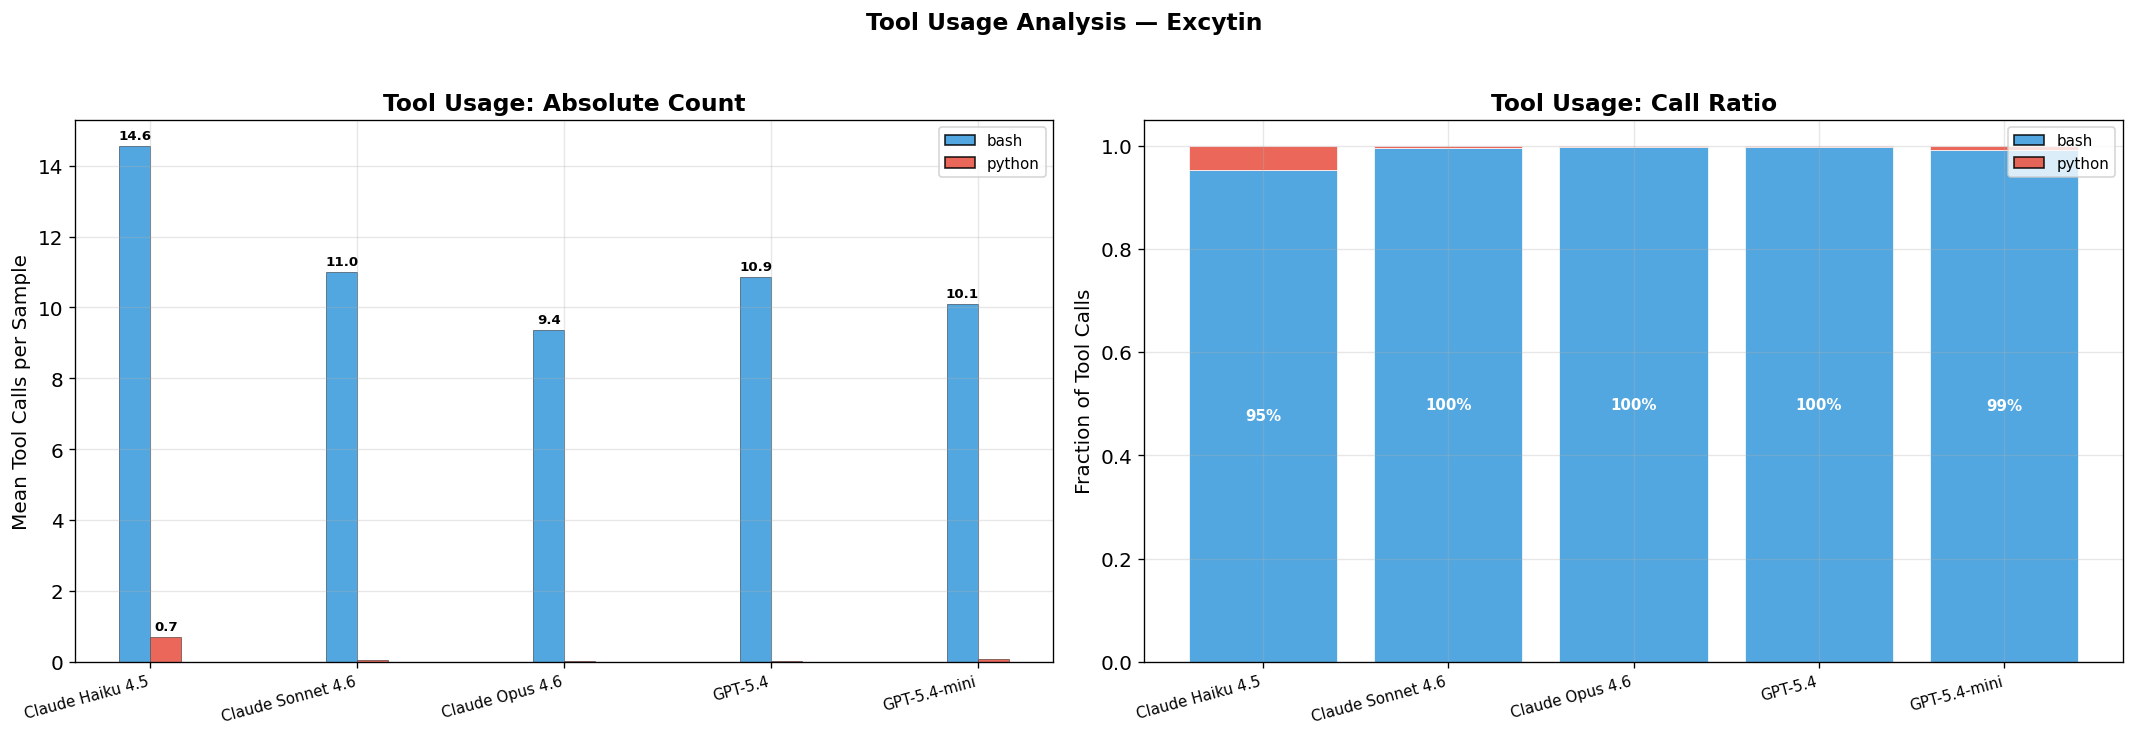

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 10: Tool usage breakdown per model
# ══════════════════════════════════════════════════════════════════════════════
tool_expanded = traj_df['tool_counts'].apply(pd.Series).fillna(0)
for col in tool_expanded.columns:
    traj_df[f'tool_{col}'] = tool_expanded[col]

tool_cols = [c for c in traj_df.columns if c.startswith('tool_') and c != 'tool_counts']
tool_names = [c.replace('tool_', '') for c in tool_cols]

# ── Aggregate minor tools (<1% of calls across all configs) into "Other" ──
total_calls_all = traj_df['n_tool_calls'].sum()
tool_totals = {tname: traj_df[col].sum() for col, tname in zip(tool_cols, tool_names)}
major_tools = [t for t, v in tool_totals.items() if v / total_calls_all >= 0.01]
minor_tools = [t for t, v in tool_totals.items() if v / total_calls_all < 0.01]

if minor_tools:
    traj_df['tool_Other (<1%)'] = sum(traj_df[f'tool_{t}'] for t in minor_tools)
    minor_label = 'Other: ' + ', '.join(minor_tools)
    plot_tool_cols = [f'tool_{t}' for t in major_tools] + ['tool_Other (<1%)']
    plot_tool_names = major_tools + [minor_label]
else:
    plot_tool_cols = tool_cols
    plot_tool_names = tool_names

tool_palette = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C', '#E67E22', '#34495E']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel 1: Mean tool calls per tool
ax = axes[0]
bar_width = 0.15
x = np.arange(len(MODEL_ORDER))
for j, (col, tname) in enumerate(zip(plot_tool_cols, plot_tool_names)):
    offset = (j - len(plot_tool_cols)/2 + 0.5) * bar_width
    means = [traj_df[traj_df['model'] == m][col].mean() for m in MODEL_ORDER]
    color = tool_palette[j % len(tool_palette)]
    ax.bar(x + offset, means, bar_width, color=color, edgecolor='black', linewidth=0.3, alpha=0.85)
    for i, v in enumerate(means):
        if v > 0.3:
            ax.text(x[i] + offset, v + 0.1, f'{v:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
tool_handles = [mpatches.Patch(facecolor=tool_palette[j % len(tool_palette)], edgecolor='black',
                                alpha=0.85, label=tname) for j, tname in enumerate(plot_tool_names)]
ax.legend(handles=tool_handles, fontsize=9, loc='upper right')
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Mean Tool Calls per Sample')
ax.set_title('Tool Usage: Absolute Count', fontweight='bold')

# Panel 2: Tool call ratios (stacked bar)
ax = axes[1]
bottoms = np.zeros(len(MODEL_ORDER))
for j, (col, tname) in enumerate(zip(plot_tool_cols, plot_tool_names)):
    ratios = []
    for m in MODEL_ORDER:
        mdf = traj_df[traj_df['model'] == m]
        total = mdf['n_tool_calls'].sum()
        ratios.append(mdf[col].sum() / total if total > 0 else 0)
    color = tool_palette[j % len(tool_palette)]
    ax.bar(x, ratios, color=color, edgecolor='white', linewidth=0.5, bottom=bottoms, alpha=0.85)
    for i, r in enumerate(ratios):
        if r > 0.05:
            ax.text(x[i], bottoms[i] + r/2, f'{r:.0%}', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    bottoms += ratios
ax.legend(handles=tool_handles, fontsize=9, loc='upper right')
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Fraction of Tool Calls')
ax.set_title('Tool Usage: Call Ratio', fontweight='bold')
ax.set_ylim(0, 1.05)

fig.suptitle(f'Tool Usage Analysis — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'tool_usage.png', bbox_inches='tight')
plt.show()

if minor_tools:
    print(f'\nTools aggregated into Other: {", ".join(minor_tools)}')

---

## 11. Time Efficiency & Reward Per Tool Call

### What this measures

Two dimensions of agent efficiency:

1. **Reward per tool call** — how much score does each model earn per unit of effort?
   $\text{Reward/Call} = \frac{\text{Mean SABER Score}}{\text{Mean Tool Calls}}$

2. **Reward per minute** — score per wall-clock minute of inference time

3. **Time per sample distribution** — how long does each model take to complete a task?

A model with high reward/call is "efficient" — it doesn't waste tool invocations. A model with low time but high reward is "fast and accurate."

### Key insights

- **Claude Opus 4.6** is the most efficient model by both metrics: **0.092 reward/call** (highest) and **0.606 reward/minute** (highest), combining the highest score with the fewest tool calls and fastest execution.
- **GPT-5.4** has a severe time efficiency problem: despite achieving the top score (0.875), it averages **12.4 minutes per sample** — ~6–9× slower than every other model. Its reward/minute (0.071) is the lowest by a wide margin, likely due to extended reasoning overhead or rate-limiting.
- **Claude Haiku 4.5** is the least efficient per tool call (0.055) because it uses the most calls for a below-average score, though it remains fast in wall-clock time (1.9m).
- The time distribution panel reveals a striking bimodal pattern for GPT-5.4 with samples ranging from ~1 minute to the 60-minute limit, while Claude models cluster tightly under 5 minutes.

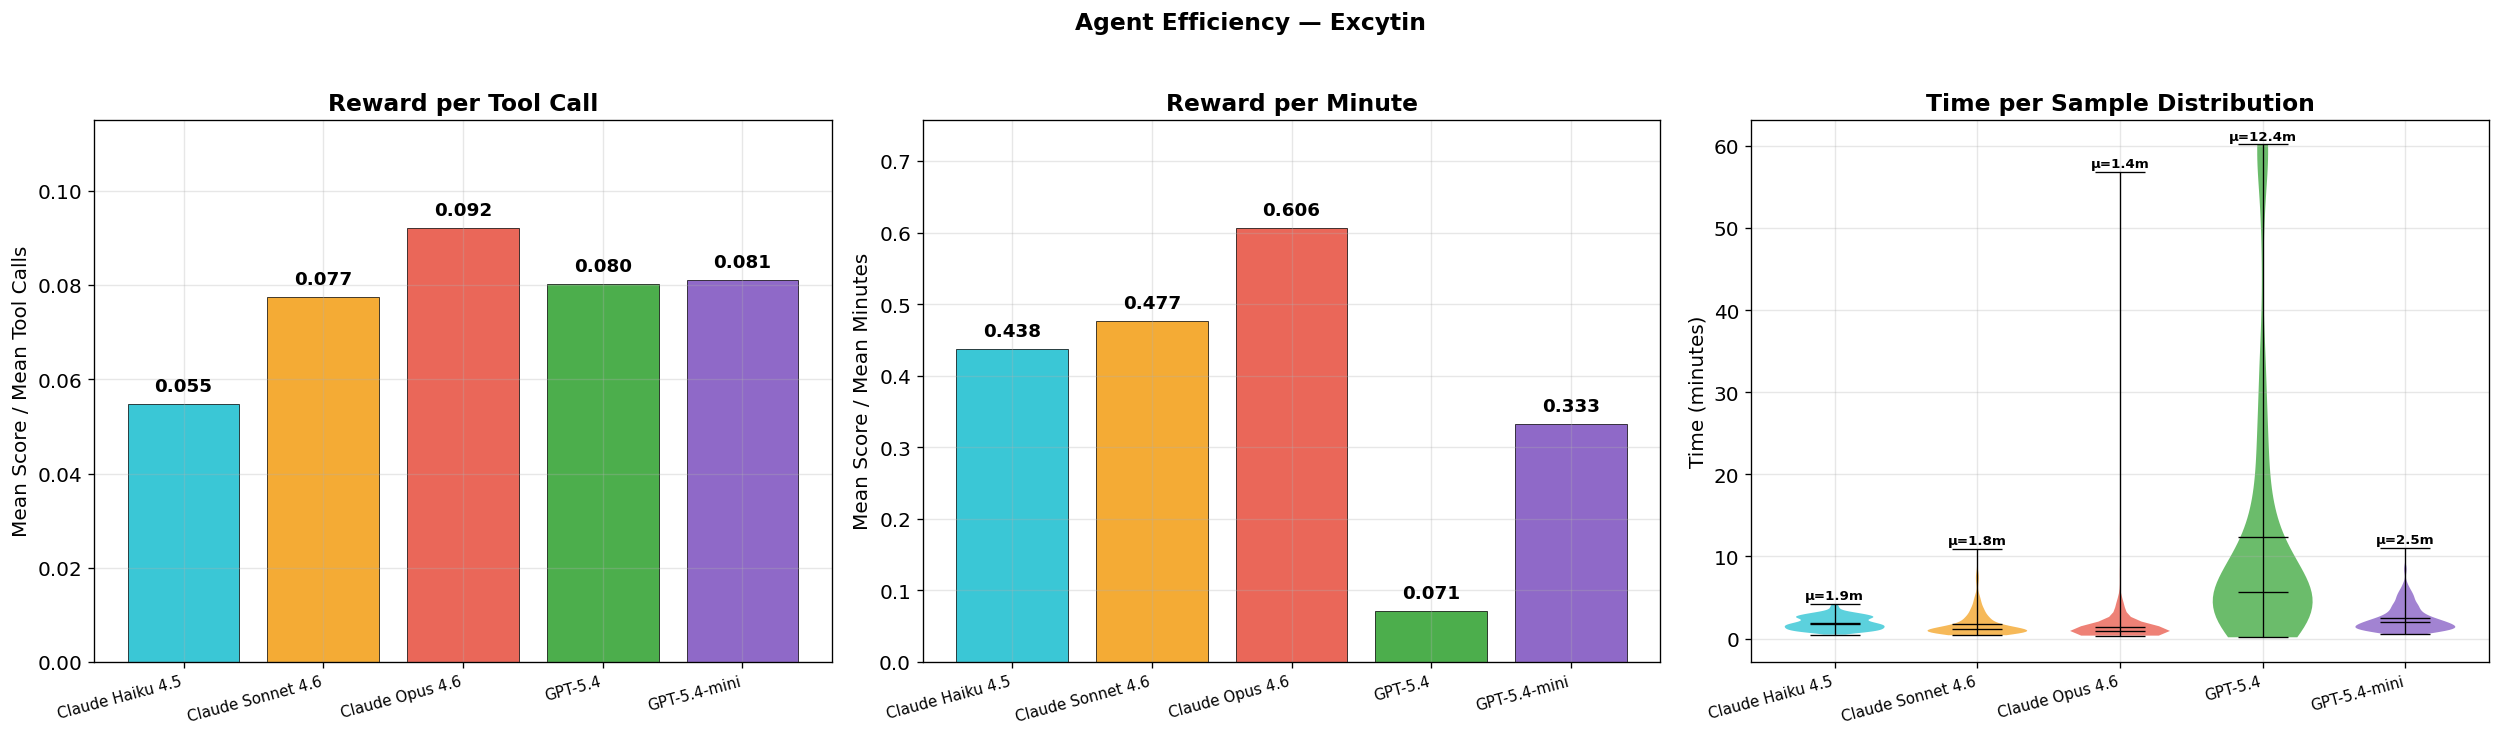

═══ Efficiency Summary ═══
Model                      Score   Calls    Time   Rew/Call    Rew/Min
──────────────────────────────────────────────────────────────────────
Claude Haiku 4.5           0.838    15.3    1.9m     0.0548     0.4378
Claude Sonnet 4.6          0.857    11.1    1.8m     0.0774     0.4769
Claude Opus 4.6            0.865     9.4    1.4m     0.0921     0.6062
GPT-5.4                    0.875    10.9   12.4m     0.0803     0.0707
GPT-5.4-mini               0.827    10.2    2.5m     0.0811     0.3331


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 11: Time efficiency and reward per tool call
# ══════════════════════════════════════════════════════════════════════════════
n_panels = 3 if N_SAMPLES >= 3 else 2
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 6))

# Panel 1: Reward per tool call
ax = axes[0]
reward_per_call = []
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m]
    mean_calls = mdf['n_tool_calls'].mean()
    rpc = mdf['score'].mean() / mean_calls if mean_calls > 0 else 0
    reward_per_call.append(rpc)
for i, (m, rpc) in enumerate(zip(MODEL_ORDER, reward_per_call)):
    ax.bar(i, rpc, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, rpc + max(reward_per_call)*0.02, f'{rpc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Mean Score / Mean Tool Calls')
ax.set_title('Reward per Tool Call', fontweight='bold')
ax.set_ylim(0, max(reward_per_call) * 1.25)

# Panel 2: Reward per minute
ax = axes[1]
reward_per_min = []
for m in MODEL_ORDER:
    mdf = traj_df[traj_df['model'] == m]
    mean_time = mdf['total_time'].mean() / 60
    rpm = mdf['score'].mean() / mean_time if mean_time > 0 else 0
    reward_per_min.append(rpm)
for i, (m, rpm) in enumerate(zip(MODEL_ORDER, reward_per_min)):
    ax.bar(i, rpm, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, rpm + max(reward_per_min)*0.02, f'{rpm:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Mean Score / Mean Minutes')
ax.set_title('Reward per Minute', fontweight='bold')
ax.set_ylim(0, max(reward_per_min) * 1.25)

# Panel 3: Time per sample distributions (only if enough samples)
if N_SAMPLES >= 3:
    ax = axes[2]
    for i, m in enumerate(MODEL_ORDER):
        data = traj_df[traj_df['model'] == m]['total_time'].values / 60
        vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
        for pc in vp['bodies']:
            pc.set_facecolor(COLORS[m])
            pc.set_alpha(0.7)
        for part in ('cmaxes', 'cmins', 'cbars', 'cmeans', 'cmedians'):
            if part in vp:
                vp[part].set_edgecolor('black')
                vp[part].set_linewidth(0.8)
        ax.text(i, data.max() + 0.2, f'μ={np.mean(data):.1f}m', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
    ax.set_ylabel('Time (minutes)')
    ax.set_title('Time per Sample Distribution', fontweight='bold')

fig.suptitle(f'Agent Efficiency — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'agent_efficiency.png', bbox_inches='tight')
plt.show()

# Summary table
print('═══ Efficiency Summary ═══')
print(f'{"Model":25s} {"Score":>6s} {"Calls":>7s} {"Time":>7s} {"Rew/Call":>10s} {"Rew/Min":>10s}')
print('─' * 70)
for m, rpc, rpm in zip(MODEL_ORDER, reward_per_call, reward_per_min):
    mdf = traj_df[traj_df['model'] == m]
    print(f'{m:25s} {mdf["score"].mean():6.3f} {mdf["n_tool_calls"].mean():7.1f} '
          f'{mdf["total_time"].mean()/60:6.1f}m {rpc:10.4f} {rpm:10.4f}')

---

## 12. Score Outcome Segmentation by Effort

### What this measures

Segments samples into **effort quartiles** by tool-call count and shows what fraction of tasks in each quartile achieve a **perfect score** (1.0) vs. **zero** (0.0) vs. **partial** (0 < score < 1).

This reveals whether:
- High-effort tasks are the ones the model struggles with (many tool calls → partial/zero)
- Quick tasks are easy wins (few tool calls → perfect score)
- More tool calls actually convert to better outcomes

### Key insights

- Across all five models the pattern is consistent: **Q1 (lowest effort) tasks have the highest perfect-score rate** (78–85%) while **Q4 (highest effort) tasks degrade** to 63–76%. More tool calls generally signal harder tasks, not better outcomes.
- The **zero-score fraction rises in Q4** for every model — e.g., Haiku goes from 2% zero in Q1 to 17% in Q4, and GPT-5.4-mini from 7% to 21%. These are tasks where the agent exhausted its budget without solving the problem.
- **Partial scores (orange)** grow in higher quartiles too, showing models that partially solve the task but cannot finish within the tool-call budget.
- Claude Opus 4.6 maintains the best Q4 performance (72% perfect) suggesting it degrades the most gracefully on hard tasks, while Haiku (63%) and GPT-5.4-mini (69%) suffer the steepest drops.

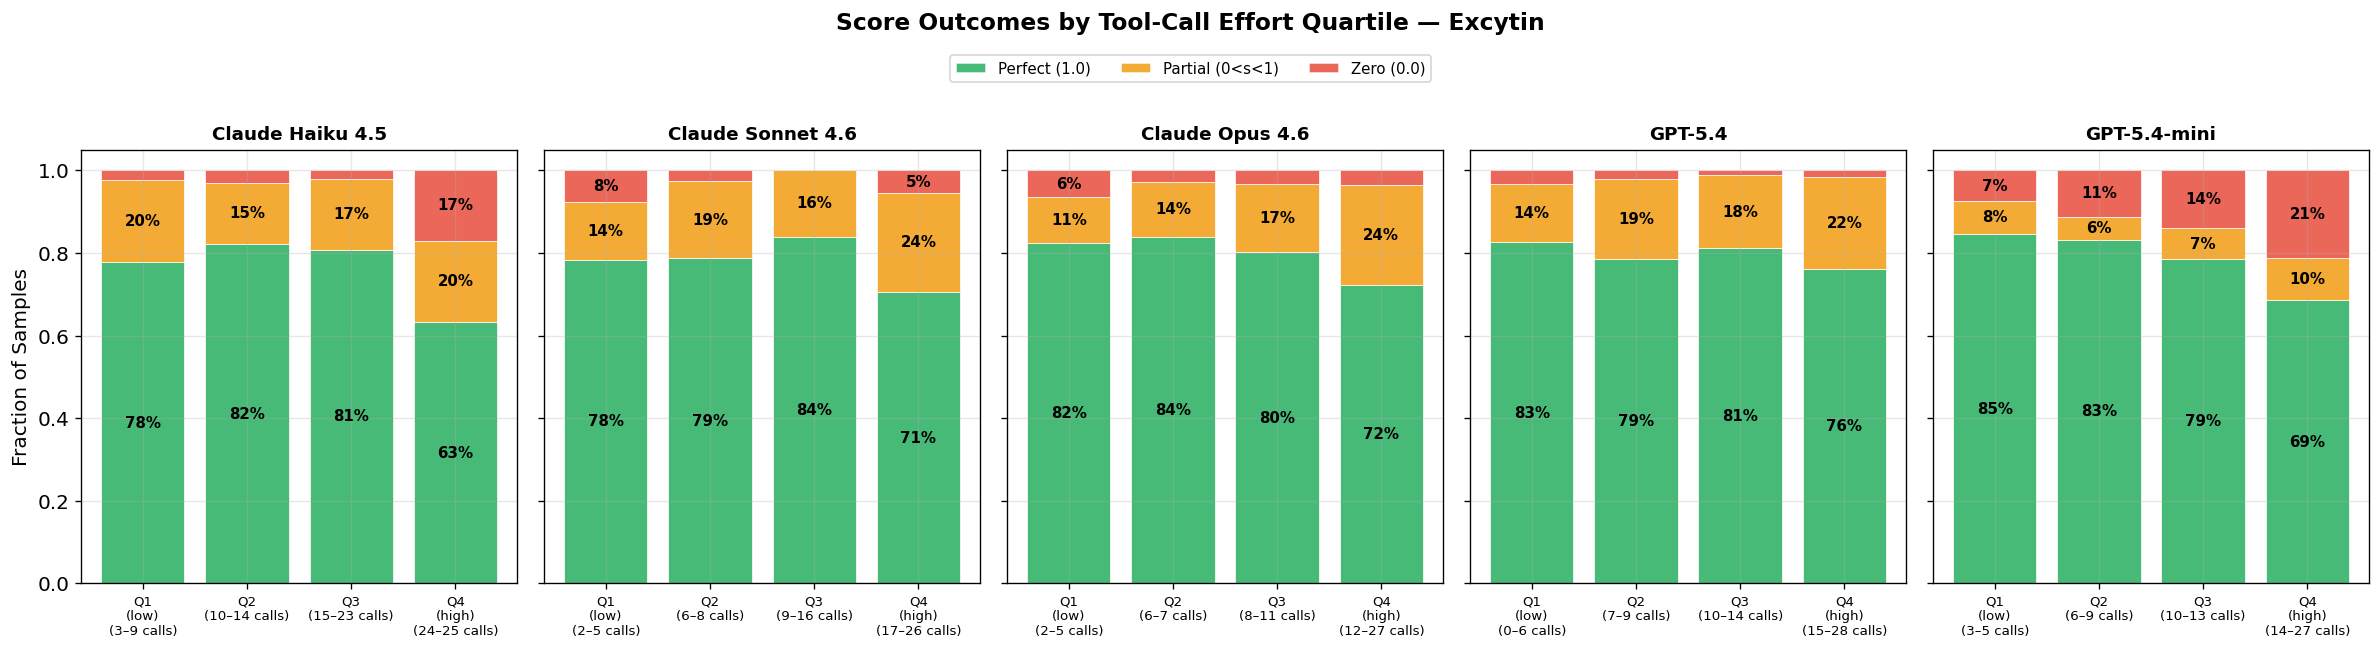

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 12: Score outcome segmentation by tool-call effort quartile
# ══════════════════════════════════════════════════════════════════════════════
if N_SAMPLES < 8:
    print(f'⚠ Only {N_SAMPLES} sample(s) per model — skipping effort quartile analysis (need ≥8 for meaningful quartiles)')
    print()
    for m in MODEL_ORDER:
        mdf = traj_df[traj_df['model'] == m]
        for _, row in mdf.iterrows():
            outcome = 'Perfect' if row['score'] >= 1.0 - 1e-6 else ('Zero' if row['score'] <= 1e-6 else 'Partial')
            print(f'  {m:25s}  calls={int(row["n_tool_calls"]):2d}  score={row["score"]:.3f}  → {outcome}')
else:
    outcome_colors = {'Perfect (1.0)': '#27AE60', 'Partial (0<s<1)': '#F39C12', 'Zero (0.0)': '#E74C3C'}
    n_models = len(MODEL_ORDER)
    fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 5), sharey=True)
    if n_models == 1:
        axes = [axes]

    for ax, m in zip(axes, MODEL_ORDER):
        mdf = traj_df[traj_df['model'] == m].copy()
        mdf['effort_q'] = pd.qcut(mdf['n_tool_calls'], q=4, labels=['Q1\n(low)', 'Q2', 'Q3', 'Q4\n(high)'], duplicates='drop')

        mdf['outcome'] = 'Partial (0<s<1)'
        mdf.loc[mdf['score'] >= 1.0 - 1e-6, 'outcome'] = 'Perfect (1.0)'
        mdf.loc[mdf['score'] <= 1e-6, 'outcome'] = 'Zero (0.0)'

        ct = pd.crosstab(mdf['effort_q'], mdf['outcome'], normalize='index')
        ct = ct.reindex(columns=['Perfect (1.0)', 'Partial (0<s<1)', 'Zero (0.0)'], fill_value=0)

        bottoms = np.zeros(len(ct))
        for outcome_cat in ['Perfect (1.0)', 'Partial (0<s<1)', 'Zero (0.0)']:
            if outcome_cat not in ct.columns:
                continue
            vals = ct[outcome_cat].values
            ax.bar(range(len(ct)), vals, bottom=bottoms, color=outcome_colors[outcome_cat],
                   edgecolor='white', linewidth=0.5, alpha=0.85)
            for xi, (v, b) in enumerate(zip(vals, bottoms)):
                if v > 0.05:
                    ax.text(xi, b + v/2, f'{v:.0%}', ha='center', va='center', fontsize=9, fontweight='bold')
            bottoms += vals

        call_ranges = mdf.groupby('effort_q')['n_tool_calls'].agg(['min', 'max'])
        xlabels = [f'{r.Index}\n({int(r.min)}–{int(r.max)} calls)' for r in call_ranges.itertuples()]
        ax.set_xticks(range(len(ct)))
        ax.set_xticklabels(xlabels, fontsize=8)
        ax.set_title(m, fontweight='bold', fontsize=11)
        ax.set_ylim(0, 1.05)

    axes[0].set_ylabel('Fraction of Samples')
    handles = [mpatches.Patch(facecolor=c, edgecolor='white', alpha=0.85, label=k) for k, c in outcome_colors.items()]
    fig.legend(handles=handles, loc='upper center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f'Score Outcomes by Tool-Call Effort Quartile — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.08)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / 'effort_outcome_segmentation.png', bbox_inches='tight')
    plt.show()

---

## 13. Cross-Model Difficulty Agreement

### What this measures

Do models agree on which tasks are hard? For each pair of models, computes the **Spearman rank correlation** of their per-sample scores.

- **High correlation (> 0.7)** = models agree on task difficulty — some tasks are inherently harder
- **Low correlation (< 0.3)** = models struggle on different tasks — strengths are complementary
- Useful for **ensemble strategies**: low correlation = models complement each other

### Key insights

- All pairwise correlations are **moderate** (ρ = 0.41–0.64) and statistically significant (p < 0.05), confirming that task difficulty is partly intrinsic — harder incidents are harder for everyone.
- The **strongest agreement** is between Claude Sonnet 4.6 and Claude Opus 4.6 (ρ = 0.635), which makes sense given they share the same model family and likely approach tasks similarly.
- The **weakest agreement** is between GPT-5.4 and GPT-5.4-mini (ρ = 0.408), surprisingly low for same-family models — suggesting the mini variant takes meaningfully different approaches to the same tasks.
- Cross-family correlations (Claude vs. GPT) hover around ρ ≈ 0.47–0.53, indicating moderate agreement but enough divergence that an **ensemble of Claude + GPT models** could capture complementary strengths.
- None of the correlations exceed 0.7, so no two models are near-redundant — every model brings a partially unique perspective on task difficulty.

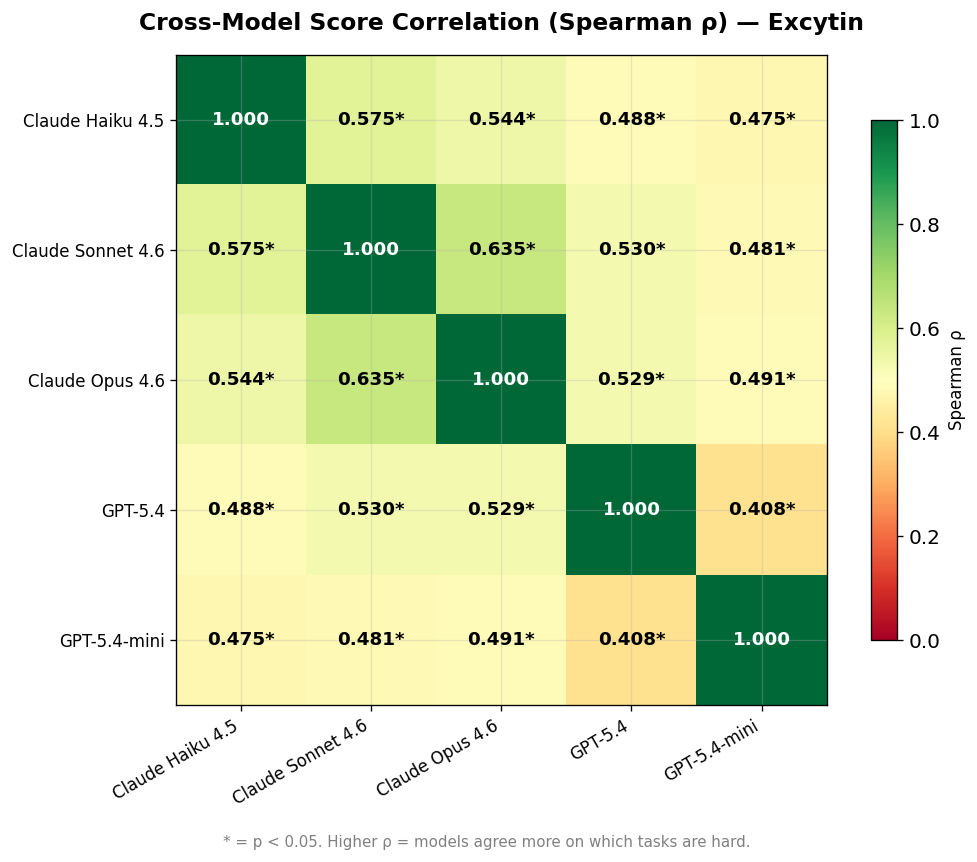

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 13: Cross-model difficulty agreement (Spearman correlation heatmap)
# ══════════════════════════════════════════════════════════════════════════════
from scipy.stats import spearmanr

if N_SAMPLES < 3:
    print(f'⚠ Only {N_SAMPLES} sample(s) — skipping correlation analysis (need ≥3 for Spearman)')
    print()
    for m in MODEL_ORDER:
        mdf = traj_df[traj_df['model'] == m]
        print(f'  {m:25s}  score={mdf["score"].mean():.3f}')
else:
    score_pivot = samples_df.pivot(index='sample_id', columns='model', values='score').reindex(columns=MODEL_ORDER)

    n = len(MODEL_ORDER)
    corr_matrix = np.ones((n, n))
    p_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            m1, m2 = MODEL_ORDER[i], MODEL_ORDER[j]
            valid = score_pivot[[m1, m2]].dropna()
            if len(valid) > 2:
                rho, p = spearmanr(valid[m1], valid[m2])
                corr_matrix[i, j] = corr_matrix[j, i] = rho
                p_matrix[i, j] = p_matrix[j, i] = p

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='equal')

    for i in range(n):
        for j in range(n):
            val = corr_matrix[i, j]
            text_color = 'white' if val < 0.4 or val > 0.85 else 'black'
            sig = '' if i == j else ('*' if p_matrix[i, j] < 0.05 else '')
            ax.text(j, i, f'{val:.3f}{sig}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color=text_color)

    ax.set_xticks(range(n)); ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right', fontsize=10)
    ax.set_yticks(range(n)); ax.set_yticklabels(MODEL_ORDER, fontsize=10)
    ax.set_title(f'Cross-Model Score Correlation (Spearman ρ) — {DOMAIN_NAME}', fontweight='bold', pad=15)
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Spearman ρ', fontsize=10)
    fig.text(0.5, -0.02, '* = p < 0.05. Higher ρ = models agree more on which tasks are hard.',
             ha='center', fontsize=9, fontstyle='italic', color='gray')
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / 'cross_model_correlation.png', bbox_inches='tight')
    plt.show()

---

## 14. SQL Query Analysis (Excytin-Specific)

### What this measures

Excytin agents investigate security incidents by querying a SQL database through the `bash` tool. This analysis extracts every SQL query from agent tool calls and classifies the **query response outcomes**:

- **Success (≤100 rows)** — query returned a manageable result the agent can parse
- **Large result (>100 rows)** — query returned too many rows to parse efficiently; agent should refine
- **Empty result** — query returned no rows (wrong table, bad filter, or no matching data)
- **Error** — syntax error, missing table, permission denied, etc.

### Why this matters

Agents that write precise, targeted queries will have **higher success rates** and **lower error/empty rates**. Models that repeatedly hit errors or get empty results waste tool calls on fruitless investigation — correlating with lower scores and higher effort.

### Key insights

- **33,425 SQL queries** extracted across all 5 models — roughly **5.6 queries per tool call** on average, meaning most bash invocations involve SQL.
- **Claude Opus 4.6** has the best query quality: **79% success rate**, only 0.5% errors, and 19.5% empty results — it writes precisely targeted queries.
- **GPT-5.4-mini** has the worst query discipline: only 61% success, **7.0% error rate** (highest), and 6.1% large results — it frequently writes syntactically incorrect or overly broad queries.
- **GPT-5.4** has few errors (2.3%) but the second-highest large-result rate (5.7%), suggesting it writes correct but overly broad `SELECT` statements without `LIMIT` or `WHERE` clauses.
- **Empty results** are the dominant failure mode across all models (19–33%), far exceeding errors — agents spend most of their wasted effort querying valid tables that simply don't contain the expected data.
- The **Success Rate vs. Score scatter** shows a positive trend (Opus: 79% success → 0.865 score; GPT-5.4-mini: 61% success → 0.827 score) — although GPT-5.4 breaks the pattern by achieving the highest score (0.875) with only 70% query success, suggesting it compensates with other strategies.
- **SQL error rate has no statistically significant correlation with individual sample scores** (p > 0.14 for all models) — errors per se don't doom a sample; models recover by retrying. The broader pattern of wasted tool calls matters more than individual query failures.

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 14 (EXCYTIN-SPECIFIC): SQL Query Analysis
# ══════════════════════════════════════════════════════════════════════════════
import re
import zipfile
import json as _json
from inspect_ai.log import read_eval_log_sample

# SQL detection patterns (queries sent via bash tool)
SQL_PATTERN = re.compile(
    r'\b(SELECT|INSERT|UPDATE|DELETE|CREATE|DROP|ALTER|SHOW|DESCRIBE|EXPLAIN|USE|WITH)\b',
    re.IGNORECASE
)
ERROR_PATTERNS = re.compile(
    r"(ERROR\s+\d+|error:|syntax error|no such table|unknown column|access denied|doesn.t exist|command not found|permission denied|You have an error)",
    re.IGNORECASE
)
EMPTY_PATTERNS = re.compile(r'(Empty set|0 rows|\(0 rows\)|^\s*$)')
ROW_COUNT_PATTERN = re.compile(r'(\d+) rows? in set')

def classify_query_result(result_text: str) -> str:
    """Classify a SQL query result into success/error/empty/large."""
    if not result_text or result_text.strip() == '':
        return 'empty'
    if ERROR_PATTERNS.search(result_text):
        return 'error'
    if EMPTY_PATTERNS.search(result_text.strip()):
        return 'empty'
    m = ROW_COUNT_PATTERN.search(result_text)
    if m:
        n_rows = int(m.group(1))
        if n_rows == 0:
            return 'empty'
        elif n_rows > 100:
            return 'large_result'
        else:
            return 'success'
    # Heuristic: count lines (each line ≈ one row in tabular output)
    content_lines = [l for l in result_text.strip().split('\n') if l.strip() and not l.startswith('+')]
    if len(content_lines) <= 2:
        return 'empty'
    elif len(content_lines) > 102:
        return 'large_result'
    else:
        return 'success'

def extract_sql_queries(path: str, sample_id: str) -> list[dict]:
    """Extract SQL queries and results from a sample."""
    queries = []
    try:
        sample = read_eval_log_sample(path, id=sample_id)
        messages = sample.messages
        for i, msg in enumerate(messages):
            if hasattr(msg, 'tool_calls') and msg.tool_calls:
                for tc in msg.tool_calls:
                    if tc.function != 'bash':
                        continue
                    cmd = ''
                    if isinstance(tc.arguments, dict):
                        cmd = tc.arguments.get('cmd', '') or tc.arguments.get('command', '') or str(tc.arguments)
                    elif isinstance(tc.arguments, str):
                        cmd = tc.arguments
                    if not SQL_PATTERN.search(cmd):
                        continue
                    result_text = ''
                    for j in range(i+1, min(i+5, len(messages))):
                        rmsg = messages[j]
                        if hasattr(rmsg, 'tool_call_id') and rmsg.tool_call_id == tc.id:
                            if isinstance(rmsg.content, str):
                                result_text = rmsg.content
                            elif isinstance(rmsg.content, list):
                                result_text = ' '.join(
                                    getattr(c, 'text', str(c)) for c in rmsg.content
                                )
                            break
                    queries.append({
                        'command': cmd[:500],
                        'result_class': classify_query_result(result_text),
                        'result_length': len(result_text),
                    })
    except Exception:
        try:
            with zipfile.ZipFile(path) as z:
                for name in z.namelist():
                    if not (name.startswith('samples/') and name.endswith('.json')):
                        continue
                    raw = _json.loads(z.read(name))
                    if str(raw.get('id', '')) != sample_id:
                        continue
                    messages_raw = raw.get('messages', [])
                    for i, msg in enumerate(messages_raw):
                        if msg.get('role') != 'assistant':
                            continue
                        for tc in msg.get('tool_calls', []):
                            if tc.get('function', '') != 'bash':
                                continue
                            args = tc.get('arguments', {})
                            cmd = args.get('cmd', '') or args.get('command', '') or str(args)
                            if not SQL_PATTERN.search(cmd):
                                continue
                            result_text = ''
                            tc_id = tc.get('id', '')
                            for j in range(i+1, min(i+5, len(messages_raw))):
                                rmsg = messages_raw[j]
                                if rmsg.get('tool_call_id') == tc_id:
                                    content = rmsg.get('content', '')
                                    result_text = content if isinstance(content, str) else str(content)
                                    break
                            queries.append({
                                'command': cmd[:500],
                                'result_class': classify_query_result(result_text),
                                'result_length': len(result_text),
                            })
                    break
        except Exception:
            pass
    return queries

# Extract SQL queries from all samples
print('Extracting SQL queries from all samples (this may take a minute)...')
sql_rows = []
for model_name, log_file in EVAL_LOGS.items():
    path = os.path.join(LOG_DIR, log_file)
    sample_ids = traj_df[traj_df['model'] == model_name]['sample_id'].tolist()
    for sid in sample_ids:
        for q in extract_sql_queries(path, sid):
            q['model'] = model_name
            q['sample_id'] = sid
            sql_rows.append(q)

sql_df = pd.DataFrame(sql_rows)
print(f'✓ Extracted {len(sql_df)} SQL queries across {sql_df["model"].nunique()} models')
print()

# Summary per model
print('═══ SQL Query Summary per Model ═══')
print(f'{"Model":25s} {"Total":>6s} {"Success":>8s} {"Empty":>8s} {"Error":>8s} {"Large":>8s} {"Queries/Sample":>15s}')
print('─' * 85)
for m in MODEL_ORDER:
    mq = sql_df[sql_df['model'] == m]
    n_samples = len(traj_df[traj_df['model'] == m])
    total = len(mq)
    success = (mq['result_class'] == 'success').sum()
    empty = (mq['result_class'] == 'empty').sum()
    error = (mq['result_class'] == 'error').sum()
    large = (mq['result_class'] == 'large_result').sum()
    per_sample = total / n_samples if n_samples > 0 else 0
    print(f'{m:25s} {total:6d} {success:7d} ({success/total*100 if total else 0:4.1f}%) '
          f'{empty:5d} ({empty/total*100 if total else 0:4.1f}%) '
          f'{error:5d} ({error/total*100 if total else 0:4.1f}%) '
          f'{large:5d} ({large/total*100 if total else 0:4.1f}%) '
          f'{per_sample:14.1f}')

Extracting SQL queries from all samples (this may take a minute)...
✓ Extracted 33425 SQL queries across 5 models

═══ SQL Query Summary per Model ═══
Model                      Total  Success    Empty    Error    Large  Queries/Sample
─────────────────────────────────────────────────────────────────────────────────────
Claude Haiku 4.5            8672    5514 (63.6%)  2850 (32.9%)   207 ( 2.4%)   101 ( 1.2%)           14.5
Claude Sonnet 4.6           6597    4634 (70.2%)  1776 (26.9%)    99 ( 1.5%)    88 ( 1.3%)           11.0
Claude Opus 4.6             5610    4421 (78.8%)  1094 (19.5%)    28 ( 0.5%)    67 ( 1.2%)            9.4
GPT-5.4                     6493    4528 (69.7%)  1447 (22.3%)   150 ( 2.3%)   368 ( 5.7%)           10.8
GPT-5.4-mini                6053    3673 (60.7%)  1587 (26.2%)   426 ( 7.0%)   367 ( 6.1%)           10.1


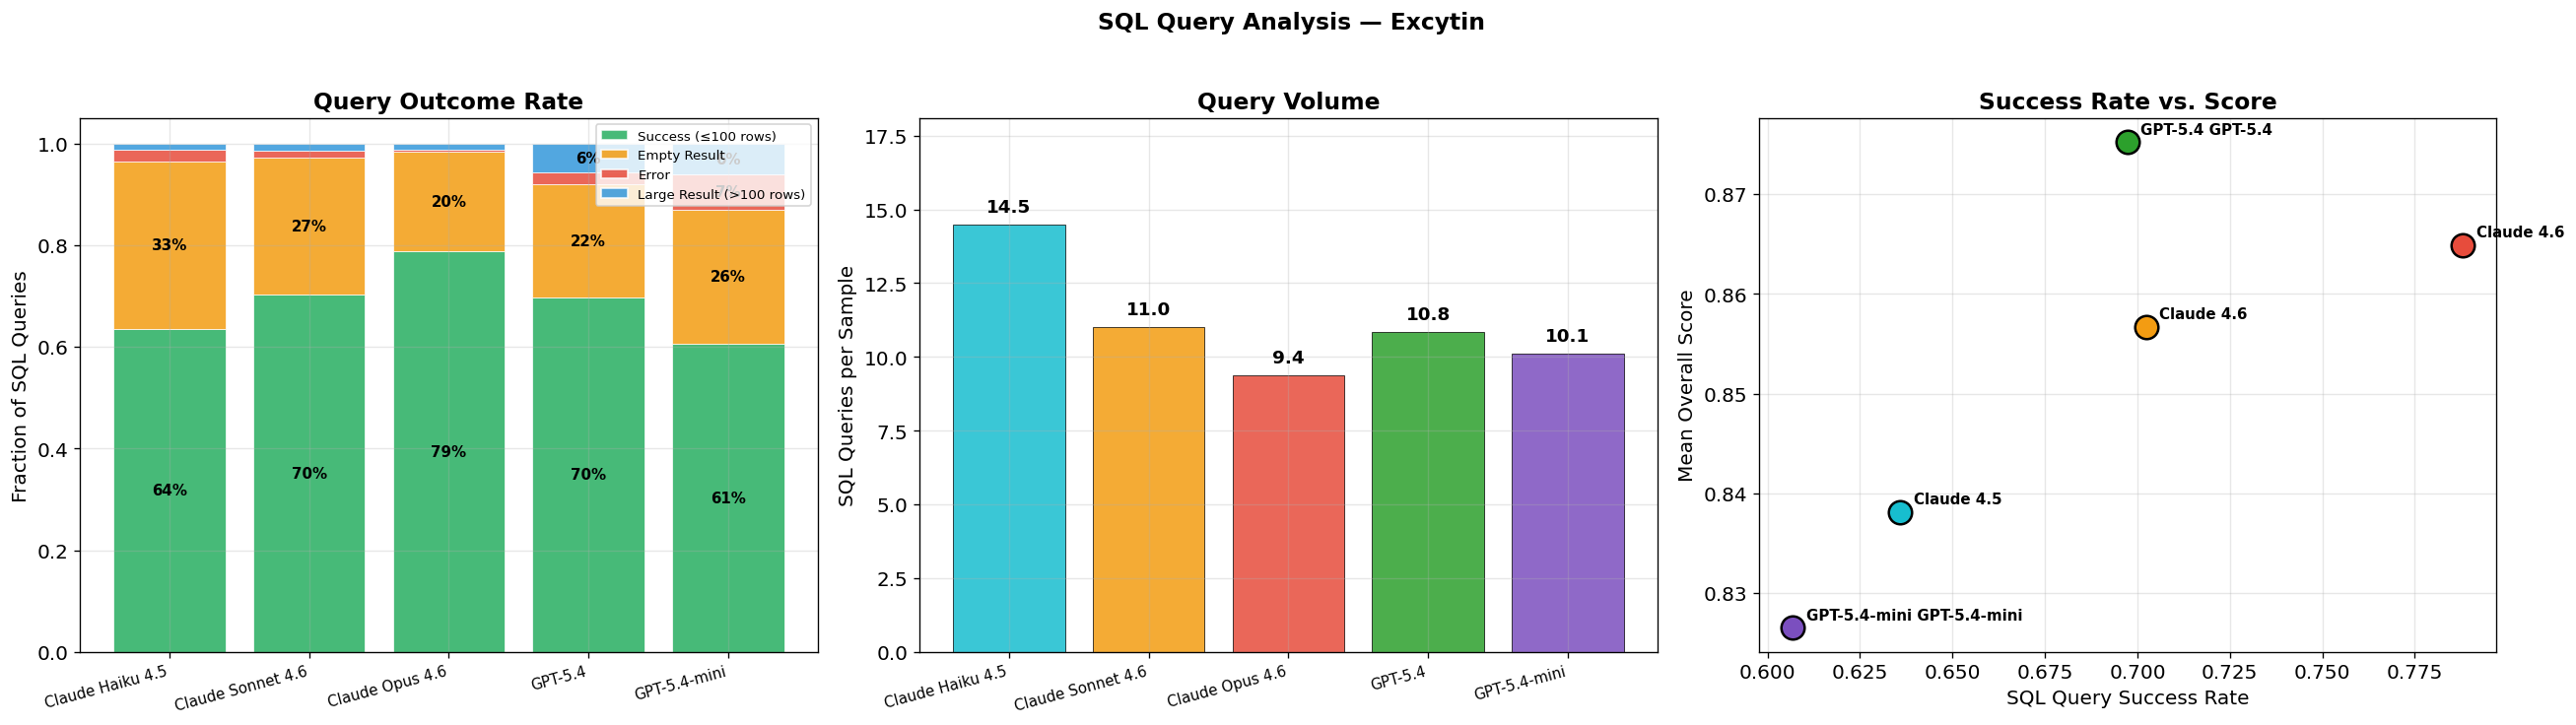

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 14b: SQL Query Outcome Visualization
# ══════════════════════════════════════════════════════════════════════════════
result_classes = ['success', 'empty', 'error', 'large_result']
result_labels = ['Success (≤100 rows)', 'Empty Result', 'Error', 'Large Result (>100 rows)']
result_colors = ['#27AE60', '#F39C12', '#E74C3C', '#3498DB']

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Panel 1: Query outcome rate per model (stacked bar)
ax = axes[0]
x = np.arange(len(MODEL_ORDER))
bottoms = np.zeros(len(MODEL_ORDER))
handles = []
for rc, label, color in zip(result_classes, result_labels, result_colors):
    rates = []
    for m in MODEL_ORDER:
        mq = sql_df[sql_df['model'] == m]
        rates.append((mq['result_class'] == rc).sum() / len(mq) if len(mq) > 0 else 0)
    bars = ax.bar(x, rates, bottom=bottoms, color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
    handles.append(mpatches.Patch(facecolor=color, edgecolor='white', alpha=0.85, label=label))
    for i, (r, b) in enumerate(zip(rates, bottoms)):
        if r > 0.04:
            ax.text(x[i], b + r/2, f'{r:.0%}', ha='center', va='center', fontsize=9, fontweight='bold')
    bottoms += rates
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Fraction of SQL Queries')
ax.set_title('Query Outcome Rate', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(handles=handles, fontsize=8, loc='upper right')

# Panel 2: Queries per sample (bar)
ax = axes[1]
queries_per_sample = []
for m in MODEL_ORDER:
    n_q = len(sql_df[sql_df['model'] == m])
    n_s = len(traj_df[traj_df['model'] == m])
    queries_per_sample.append(n_q / n_s if n_s > 0 else 0)
for i, (m, qps) in enumerate(zip(MODEL_ORDER, queries_per_sample)):
    ax.bar(i, qps, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, qps + max(queries_per_sample)*0.02, f'{qps:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('SQL Queries per Sample')
ax.set_title('Query Volume', fontweight='bold')
ax.set_ylim(0, max(queries_per_sample) * 1.25)

# Panel 3: Success rate vs. overall score (scatter)
ax = axes[2]
for i, m in enumerate(MODEL_ORDER):
    mq = sql_df[sql_df['model'] == m]
    success_rate = (mq['result_class'] == 'success').sum() / len(mq) if len(mq) > 0 else 0
    mean_score = traj_df[traj_df['model'] == m]['score'].mean()
    ax.scatter(success_rate, mean_score, color=COLORS[m], s=200, edgecolor='black', linewidth=1.5, zorder=5)
    ax.annotate(m.split()[0] + ' ' + m.split()[-1], (success_rate, mean_score),
                textcoords='offset points', xytext=(8, 5), fontsize=9, fontweight='bold')
ax.set_xlabel('SQL Query Success Rate')
ax.set_ylabel('Mean Overall Score')
ax.set_title('Success Rate vs. Score', fontweight='bold')
ax.grid(alpha=0.3)

fig.suptitle(f'SQL Query Analysis — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'sql_query_analysis.png', bbox_inches='tight')
plt.show()

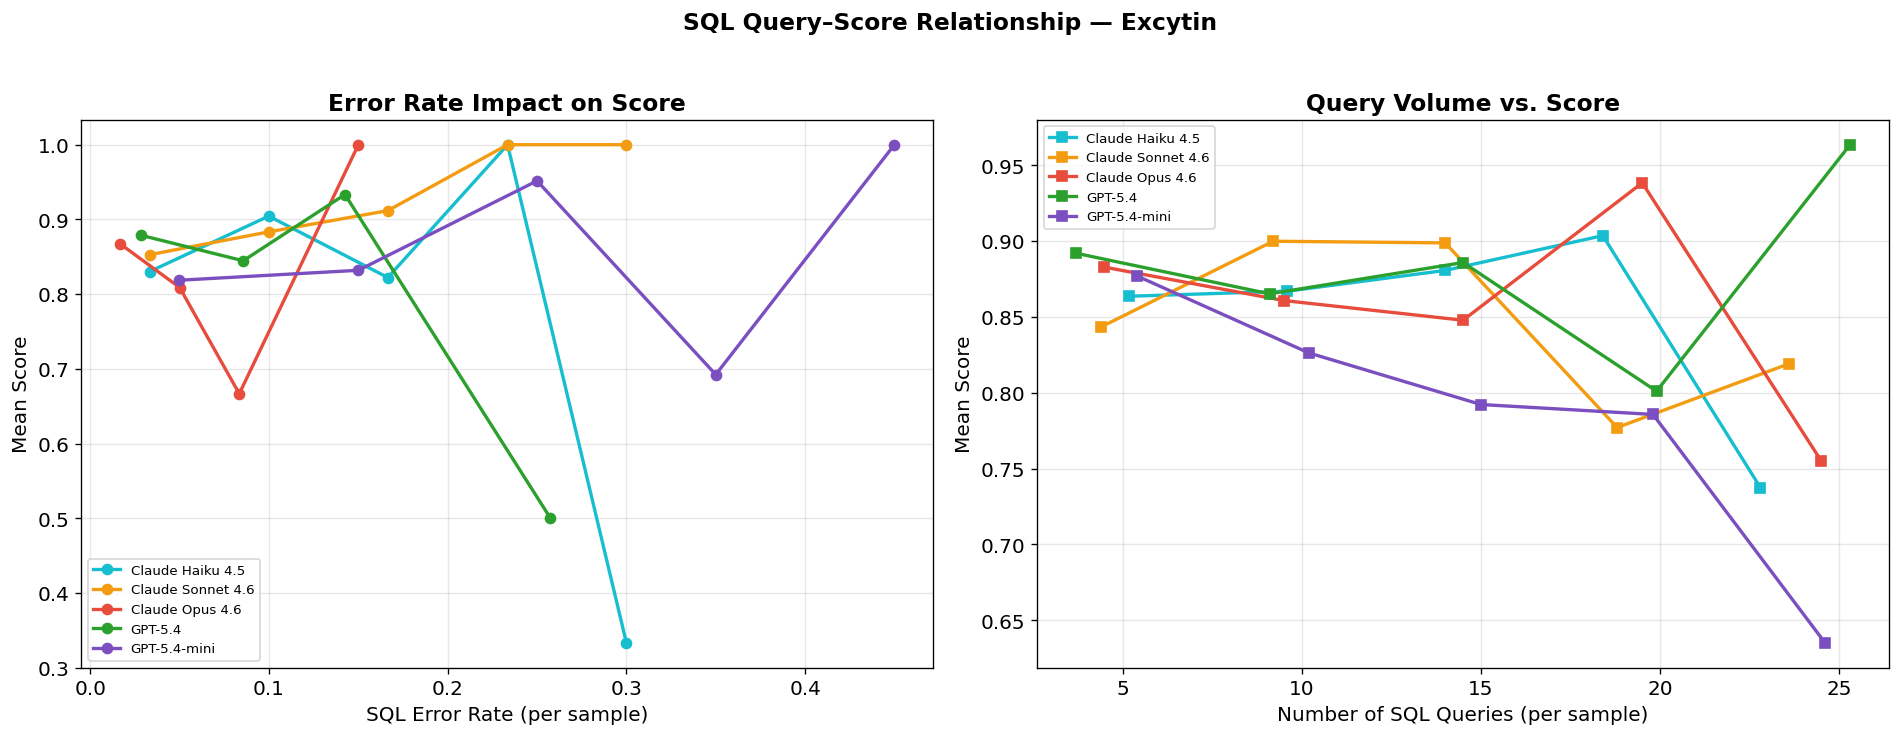

═══ SQL Error Rate → Score Correlation (per model) ═══
  Claude Haiku 4.5           ρ=+0.060  p=0.1415  (n=599 samples with SQL queries)
  Claude Sonnet 4.6          ρ=+0.004  p=0.9157  (n=599 samples with SQL queries)
  Claude Opus 4.6            ρ=-0.057  p=0.1638  (n=599 samples with SQL queries)
  GPT-5.4                    ρ=-0.025  p=0.5359  (n=598 samples with SQL queries)
  GPT-5.4-mini               ρ=-0.040  p=0.3239  (n=599 samples with SQL queries)


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 14c: SQL Query Outcome vs. Score per Sample
# ══════════════════════════════════════════════════════════════════════════════
sample_query_stats = sql_df.groupby(['model', 'sample_id']).apply(
    lambda g: pd.Series({
        'n_queries': len(g),
        'success_rate': (g['result_class'] == 'success').mean(),
        'error_rate': (g['result_class'] == 'error').mean(),
        'empty_rate': (g['result_class'] == 'empty').mean(),
    })
).reset_index()

sample_query_stats = sample_query_stats.merge(
    traj_df[['model', 'sample_id', 'score', 'n_tool_calls']],
    on=['model', 'sample_id']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Error rate vs. score (binned)
ax = axes[0]
for m in MODEL_ORDER:
    mdf = sample_query_stats[sample_query_stats['model'] == m]
    if len(mdf) < 5:
        continue
    bins = pd.cut(mdf['error_rate'], bins=5)
    grouped = mdf.groupby(bins, observed=True)['score'].mean()
    midpoints = [interval.mid for interval in grouped.index]
    ax.plot(midpoints, grouped.values, color=COLORS[m], marker='o', linewidth=2, label=m, markersize=6)
ax.set_xlabel('SQL Error Rate (per sample)')
ax.set_ylabel('Mean Score')
ax.set_title('Error Rate Impact on Score', fontweight='bold')
ax.legend(fontsize=8, loc='best')
ax.grid(alpha=0.3)

# Panel 2: Query volume vs. score (binned)
ax = axes[1]
for m in MODEL_ORDER:
    mdf = sample_query_stats[sample_query_stats['model'] == m]
    if len(mdf) < 5:
        continue
    bins = pd.cut(mdf['n_queries'], bins=5)
    grouped = mdf.groupby(bins, observed=True)['score'].mean()
    midpoints = [interval.mid for interval in grouped.index]
    ax.plot(midpoints, grouped.values, color=COLORS[m], marker='s', linewidth=2, label=m, markersize=6)
ax.set_xlabel('Number of SQL Queries (per sample)')
ax.set_ylabel('Mean Score')
ax.set_title('Query Volume vs. Score', fontweight='bold')
ax.legend(fontsize=8, loc='best')
ax.grid(alpha=0.3)

fig.suptitle(f'SQL Query–Score Relationship — {DOMAIN_NAME}', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'sql_query_score_relationship.png', bbox_inches='tight')
plt.show()

# Correlation summary
from scipy.stats import spearmanr as _spearmanr
print('═══ SQL Error Rate → Score Correlation (per model) ═══')
for m in MODEL_ORDER:
    mdf = sample_query_stats[sample_query_stats['model'] == m]
    if len(mdf) > 2:
        rho, p = _spearmanr(mdf['error_rate'], mdf['score'])
        print(f'  {m:25s}  ρ={rho:+.3f}  p={p:.4f}  (n={len(mdf)} samples with SQL queries)')

---

## Key Takeaways

### Performance

- All five models achieve strong overall scores (0.83–0.88), with **GPT-5.4** leading at 0.875 and **Claude Opus 4.6** close behind at 0.865.
- Extended reasoning provides modest improvements for the models that support it (Sonnet, Opus, GPT-5.4), with the largest lift on Sonnet (+0.012).

### Efficiency

- **Claude Opus 4.6 is the most efficient model overall**: fewest tool calls (9.4), fastest inference (1.4 min/sample), highest reward/call (0.092), and highest reward/minute (0.606).
- **GPT-5.4 has a major latency problem**: 12.4 minutes per sample vs. 1.4–2.5 for others, making it ~6× slower despite top scores. Its reward/minute (0.071) is the lowest by far.
- **Claude Haiku 4.5** is cost-efficient but effort-heavy — cheapest per sample but uses the most tool calls (15.3) for the lowest score (0.838).

### Behavioral Patterns

- Most tasks are solved in **5–15 tool calls**; the 25-call budget is sufficient for 95%+ of score potential across all models.
- Higher effort (Q4) correlates with **worse outcomes** — tasks requiring many calls have 15–20% more zero scores than easy tasks (Q1), indicating the budget limit is the binding constraint on hard tasks.
- Models show **moderate cross-model agreement** on task difficulty (ρ = 0.41–0.64), with same-family models agreeing more (Sonnet–Opus: 0.64) and cross-family pairs less (GPT-5.4–mini: 0.41).

### SQL Query Behavior (Domain-Specific)

- Agents execute ~5.6 SQL queries per tool call on average, with bash as the exclusive interface (95–100% of tool calls).
- **Query quality separates models**: Opus achieves 79% query success with only 0.5% errors, while GPT-5.4-mini achieves only 61% success with 7% errors.
- **Empty results are the #1 failure mode** (19–33% of queries), far exceeding syntax errors — agents waste effort querying tables that don't contain the expected data.
- Individual SQL errors don't predict sample scores (p > 0.14) — models recover through retries, and the cumulative cost of wasted tool calls matters more than any single failure.

---

## Next Steps

### Adding your own models

1. Run: `uv run inspect eval domains/excytin --model <model_id>`
2. Copy the `.eval` file to `eval_samples/excytin/`
3. Edit the **Configuration cell** above
4. Re-run the notebook

### Data loading notes

All log parsing uses **inspect_ai's typed log API**:
- `read_eval_log(header_only=True)` for run-level results, config, and limits
- `read_eval_log_sample_summaries()` for per-sample scores, timing, and model usage
- `read_eval_log_sample(id=...)` for full message/tool-call detail per sample

### Further reading

- **[README.md](../README.md)** — Installation, domains, agents, CLI
- `uv run inspect view` — Interactive log viewer